## 1: Data Loading & Temporal Split

In recommender system experiments, it is crucial to **split data by time** rather than randomly. Temporal splitting ensures that all interactions in the training set strictly precede those in validation and test sets, mirroring a real-world scenario where we train on past user behavior to predict the future. This approach:

* Prevents information leakage (where future data could accidentally inform past predictions),
* Produces more realistic evaluation metrics, and
* Ensures fair comparison with other models.

In our workflow, after loading all user session logs, we sort them by timestamp and split them into training (first 80%), validation (next 10%), and test (final 10%) sets. This way, the model will only be trained on user behaviors that occurred before the validation and test sessions, preserving temporal integrity.
Later, when building graphs or extracting features, each split will be used independently, and only the appropriate data subset (train/val/test) will be available to the corresponding model phase.

In [1]:
# import libraries for data loading and splitting
import pandas as pd
import numpy as np
import json
from datetime import datetime
from pathlib import Path
from collections import defaultdict
import logging
import psutil
import gc
from functools import wraps

# Optional: Pretty display for logs
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

#### Define File Paths

In [2]:
# Add file path definitions (adjust to your actual paths)
TRAIN_BEHAVIOR_PATH = Path('data/mind/small/train/behaviors.tsv')
DEV_BEHAVIOR_PATH   = Path('data/mind/small/dev/behaviors.tsv')
TRAIN_NEWS_PATH     = Path('data/mind/small/train/news_actant.jsonl')
DEV_NEWS_PATH       = Path('data/mind/small/dev/news_actant.jsonl')

### 1.1: Load, Parse, Validate Session Logs (`behaviors.tsv`)

In [3]:
def parse_impressions(imp_string):
    """
    Parse the 'impressions' field from a MIND behavior log entry.
    
    Args:
        imp_string (str): Space-separated string like "N1-1 N2-0 N3-0"
                         where each item is "news_id-label" (1=clicked, 0=not clicked)
    
    Returns:
        list of tuple: [(news_id, label), ...] where label is 1 or 0
        
    Example:
        >>> parse_impressions("N1-1 N2-0")
        [('N1', 1), ('N2', 0)]
    """
    if pd.isna(imp_string):
        return []
    return [(x.split('-')[0], int(x.split('-')[1])) for x in imp_string.strip().split()]

def parse_history(history_string):
    """
    Parse the 'history' field from a MIND behavior log entry.
    
    Args:
        history_string (str): Space-separated string of previously clicked news IDs
                             Example: "N101 N205 N350"
    
    Returns:
        list of str: List of news_id strings
        
    Example:
        >>> parse_history("N101 N205 N350")
        ['N101', 'N205', 'N350']
    """
    if pd.isna(history_string) or history_string.strip() == "":
        return []
    return history_string.strip().split()

In [4]:
# Define column names as per MIND format
columns = ['impression_id', 'user_id', 'timestamp', 'history', 'impressions']

def load_behaviors(path):
    """Load and parse behavior data with memory optimization."""
    # Use category dtype for memory efficiency with repeated strings
    df = pd.read_csv(
        path, 
        sep='\t', 
        header=None, 
        names=columns, 
        quoting=3,
        dtype={'user_id': 'category'}  # Memory optimization for repeated user IDs
    )
    
    # Convert timestamp efficiently
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Parse structured fields
    df['history'] = df['history'].apply(parse_history)
    df['impressions'] = df['impressions'].apply(parse_impressions)
    
    logging.info(f"Loaded {len(df)} behavior records from {path}")
    return df

logging.info("=== STARTING DATA LOADING ===")
train_behaviors = load_behaviors(TRAIN_BEHAVIOR_PATH)
dev_behaviors = load_behaviors(DEV_BEHAVIOR_PATH)

INFO: === STARTING DATA LOADING ===
INFO: Loaded 156965 behavior records from data/mind/small/train/behaviors.tsv
INFO: Loaded 73152 behavior records from data/mind/small/dev/behaviors.tsv


In [5]:
def validate_behaviors_data(df, name="behaviors"):
    """
    Validate loaded behavior data and log statistics for explainability.
    
    Args:
        df: Loaded behaviors DataFrame
        name: Dataset name for logging
    """
    logging.info(f"\n=== {name.upper()} DATA VALIDATION ===")
    
    # Basic statistics
    logging.info(f"Total records: {len(df):,}")
    logging.info(f"Unique users: {df['user_id'].nunique():,}")
    logging.info(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
    
    # History statistics
    history_lengths = df['history'].apply(len)
    logging.info(f"History length - Mean: {history_lengths.mean():.1f}, "
                f"Median: {history_lengths.median():.1f}, "
                f"Max: {history_lengths.max()}")
    
    # Impression statistics  
    impression_lengths = df['impressions'].apply(len)
    click_rates = df['impressions'].apply(lambda x: sum(label for _, label in x) / len(x) if x else 0)
    
    logging.info(f"Impressions per session - Mean: {impression_lengths.mean():.1f}, "
                f"Median: {impression_lengths.median():.1f}")
    logging.info(f"Click rate - Mean: {click_rates.mean():.3f}, "
                f"Median: {click_rates.median():.3f}")
    
    # Check for data quality issues
    empty_history = (history_lengths == 0).sum()
    empty_impressions = (impression_lengths == 0).sum()
    
    if empty_history > 0:
        logging.warning(f"Found {empty_history} sessions with empty history")
    if empty_impressions > 0:
        logging.warning(f"Found {empty_impressions} sessions with empty impressions")
    
    return {
        'total_records': len(df),
        'unique_users': df['user_id'].nunique(),
        'avg_history_length': history_lengths.mean(),
        'avg_click_rate': click_rates.mean()
    }

# Validate individual datasets
train_stats = validate_behaviors_data(train_behaviors, "train_behaviors")
dev_stats = validate_behaviors_data(dev_behaviors, "dev_behaviors")

INFO: 
=== TRAIN_BEHAVIORS DATA VALIDATION ===
INFO: Total records: 156,965
INFO: Unique users: 50,000
INFO: Date range: 2019-11-09 00:00:19 to 2019-11-14 23:59:13
INFO: History length - Mean: 32.5, Median: 19.0, Max: 558
INFO: Impressions per session - Mean: 37.2, Median: 24.0
INFO: Click rate - Mean: 0.109, Median: 0.056
INFO: 
=== DEV_BEHAVIORS DATA VALIDATION ===
INFO: Total records: 73,152
INFO: Unique users: 50,000
INFO: Date range: 2019-11-15 00:00:01 to 2019-11-15 23:58:03
INFO: History length - Mean: 32.3, Median: 19.0, Max: 444
INFO: Impressions per session - Mean: 37.5, Median: 23.0
INFO: Click rate - Mean: 0.100, Median: 0.059


In [6]:
# Combine train and dev behavior.tsv for temporal splitting

behaviors_df = pd.concat([train_behaviors, dev_behaviors], ignore_index=True)
del train_behaviors, dev_behaviors
gc.collect()

logging.info(f"Combined dataset: {len(behaviors_df):,} total records")
combined_stats = validate_behaviors_data(behaviors_df, "combined_behaviors")

INFO: Combined dataset: 230,117 total records
INFO: 
=== COMBINED_BEHAVIORS DATA VALIDATION ===
INFO: Total records: 230,117
INFO: Unique users: 94,057
INFO: Date range: 2019-11-09 00:00:19 to 2019-11-15 23:58:03
INFO: History length - Mean: 32.5, Median: 19.0, Max: 558
INFO: Impressions per session - Mean: 37.3, Median: 24.0
INFO: Click rate - Mean: 0.106, Median: 0.059


In [7]:
behaviors_df.head(5)

,impression_id,user_id,timestamp,history,impressions
0,1,U13740,2019-11-11 09:05:58,"[N55189, N42782, N34694, N45794, N18445, N6330...","[(N55689, 1), (N35729, 0)]"
1,2,U91836,2019-11-12 18:11:30,"[N31739, N6072, N63045, N23979, N35656, N43353...","[(N20678, 0), (N39317, 0), (N58114, 0), (N2049..."
2,3,U73700,2019-11-14 07:01:48,"[N10732, N25792, N7563, N21087, N41087, N5445,...","[(N50014, 0), (N23877, 0), (N35389, 0), (N4971..."
3,4,U34670,2019-11-11 05:28:05,"[N45729, N2203, N871, N53880, N41375, N43142, ...","[(N35729, 0), (N33632, 0), (N49685, 1), (N2758..."
4,5,U8125,2019-11-12 16:11:21,"[N10078, N56514, N14904, N33740]","[(N39985, 0), (N36050, 0), (N16096, 0), (N8400..."


### 1.2: Temporal Split

In [8]:
def temporal_split_behaviors(df, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
    """
    Perform temporal splitting with validation and memory optimization.
    
    Args:
        df: Behaviors DataFrame
        train_ratio, val_ratio, test_ratio: Split ratios (should sum to 1.0)
    
    Returns:
        DataFrame with 'split' column added
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Split ratios must sum to 1.0"
    
    # Sort by timestamp for temporal integrity
    df_sorted = df.sort_values(['timestamp', 'user_id']).reset_index(drop=True)
    
    n = len(df_sorted)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    
    # Use categorical for memory efficiency
    split_labels = ['train'] * train_end + ['val'] * (val_end - train_end) + ['test'] * (n - val_end)
    df_sorted['split'] = pd.Categorical(split_labels)
    
    # Log temporal split statistics
    logging.info(f"\n=== TEMPORAL SPLIT STATISTICS ===")
    for split in ['train', 'val', 'test']:
        split_data = df_sorted[df_sorted['split'] == split]
        logging.info(f"{split.upper()}: {len(split_data):,} records, "
                    f"{split_data['user_id'].nunique():,} users, "
                    f"dates {split_data['timestamp'].min()} to {split_data['timestamp'].max()}")
    
    return df_sorted

# Perform temporal split
behaviors_df = temporal_split_behaviors(behaviors_df)

INFO: 
=== TEMPORAL SPLIT STATISTICS ===
INFO: TRAIN: 184,093 records, 70,029 users, dates 2019-11-09 00:00:19 to 2019-11-15 08:22:54
INFO: VAL: 23,012 records, 18,948 users, dates 2019-11-15 08:22:54 to 2019-11-15 11:59:52
INFO: TEST: 23,012 records, 19,099 users, dates 2019-11-15 11:59:53 to 2019-11-15 23:58:03


In [9]:
behaviors_df.head(5)

,impression_id,user_id,timestamp,history,impressions,split
0,20112,U65916,2019-11-09 00:00:19,"[N51706, N40767, N12096, N9798, N38802, N54827...","[(N54300, 0), (N46057, 1), (N57005, 0), (N5215...",train
1,13807,U49985,2019-11-09 00:01:13,"[N5056, N29975, N53234, N39603, N50032, N8422,...","[(N20602, 0), (N50059, 0), (N57768, 1), (N5013...",train
2,27660,U25550,2019-11-09 00:02:44,"[N17260, N38298, N33976, N47719, N14888, N1887...","[(N50135, 0), (N15134, 0), (N52433, 1), (N2060...",train
3,152217,U19710,2019-11-09 00:02:50,"[N3530, N48284, N43019, N62546, N138, N13138, ...","[(N57099, 0), (N30295, 0), (N21086, 0), (N5379...",train
4,42166,U38106,2019-11-09 00:03:09,"[N16874, N264, N48697, N51366]","[(N3491, 0), (N20602, 0), (N25785, 0), (N23575...",train


### 1.3: Split-Aware Load and Filter of Actants (`news_actants.jsonl`)

Filter actants separately for each split to maintain temporal integrity.
Key Features of This Implementation:

1. Split-aware filtering: Each split filtered independently with configurable min_freq
2. Temporal integrity: Training actants don't leak into validation/test (For newly emerging narratives as the global order changes)
3. Combined vocabulary: Union of all splits for building mappings the vocabulary mapping (next step)
4. Overlap analysis: Shows how many actants are unique to each split
5. Role distribution: Analysis across all splits
6. Configurable frequencies: Easy to change min_freq_train, min_freq_val, min_freq_test

In [10]:
def load_news_json(path):
    """Load news articles with actant annotations from JSONL file."""
    news_dict = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            news_id = data.get('id') or data.get('news_id') or data.get('nid')
            if news_id:
                news_dict[news_id] = data
    return news_dict

def get_referenced_news_ids(behaviors_df):
    """Extract all news IDs referenced in behaviors (impressions + history)."""
    referenced_news_ids = set()
    
    for imps in behaviors_df['impressions']:
        referenced_news_ids.update([nid for nid, _ in imps])
    
    for history in behaviors_df['history']:
        referenced_news_ids.update(history)
    
    return referenced_news_ids

def extract_all_actants(news_dict):
    """Extract all actant-role pairs from news articles."""
    all_actant_pairs = []
    # Corrected role list based on your data
    possible_roles = ['subject', 'object', 'sender', 'receiver', 'helper', 'opponent']
    
    for news in news_dict.values():
        actants_dict = news.get('actants', {})
        
        for role in possible_roles:
            value = actants_dict.get(role)
            
            # Skip null/empty entries
            if not value or value == "none" or value == "null" or value is None:
                continue
                
            if isinstance(value, str):
                all_actant_pairs.append((value, role))
            elif isinstance(value, list):
                for actant in value:
                    if actant and actant != "none" and actant != "null" and actant is not None:
                        all_actant_pairs.append((actant, role))
    
    return all_actant_pairs

def filter_actants(actant_pairs, min_freq=3):
    """Filter actants based on banned terms, quality criteria, and frequency."""
    from collections import Counter
    import re
    
    banned_terms = {
        'none', 'you', 'the public', 'unspecified individual', 'people', 
        'someone', 'anyone', 'everybody', 'nobody', 'person', 'individual',
        'user', 'users', 'we', 'they', 'them', 'he', 'she', 'it', 'this',
        'that', 'these', 'those', 'everyone', 'everything', 'nothing',
        'something', 'anything', 'one', 'ones', 'other', 'others'
    }
    
    filter_stats = {
        'total_input': len(actant_pairs),
        'banned_terms': 0,
        'too_short': 0,
        'numbers_only': 0,
        'low_frequency': 0,
        'final_count': 0
    }
    
    # Step 1: Quality filters
    quality_filtered = []
    
    for actant_text, role in actant_pairs:
        actant_lower = actant_text.lower().strip()
        
        if actant_lower in banned_terms:
            filter_stats['banned_terms'] += 1
            continue
            
        if len(actant_text.strip()) <= 1:
            filter_stats['too_short'] += 1
            continue
            
        if re.match(r'^\d+$', actant_text.strip()):
            filter_stats['numbers_only'] += 1
            continue
            
        quality_filtered.append((actant_text, role))
    
    # Step 2: Frequency filter
    actant_freq = Counter(quality_filtered)
    
    frequency_filtered = set()
    for actant_pair, freq in actant_freq.items():
        if freq >= min_freq:
            frequency_filtered.add(actant_pair)
        else:
            filter_stats['low_frequency'] += 1
    
    filter_stats['final_count'] = len(frequency_filtered)
    
    return frequency_filtered, actant_freq, filter_stats

def filter_actants_by_split(behaviors_df, news_dict, min_freq_train=3, min_freq_val=3, min_freq_test=3):
    """
    Filter actants separately for each temporal split to maintain integrity.
    
    Args:
        behaviors_df: DataFrame with 'split' column
        news_dict: Dictionary of all news articles
        min_freq_train/val/test: Minimum frequency per split (changeable)
    
    Returns:
        dict: Split-specific filtered actants + combined vocabulary
    """
    split_actants = {}
    split_stats = {}
    min_freq_map = {'train': min_freq_train, 'val': min_freq_val, 'test': min_freq_test}
    
    for split_name in ['train', 'val', 'test']:
        logging.info(f"\n--- Processing {split_name.upper()} split ---")
        
        # Get behaviors for this split
        split_behaviors = behaviors_df[behaviors_df['split'] == split_name]
        logging.info(f"{split_name} behaviors: {len(split_behaviors):,} records")
        
        # Get referenced news IDs for this split
        split_referenced_news = get_referenced_news_ids(split_behaviors)
        logging.info(f"{split_name} referenced news: {len(split_referenced_news):,}")
        
        # Filter news dict for this split
        split_news_dict = {
            nid: news_dict[nid] 
            for nid in split_referenced_news 
            if nid in news_dict
        }
        logging.info(f"{split_name} news with actants: {len(split_news_dict):,}")
        
        # Extract actants for this split
        split_actant_pairs = extract_all_actants(split_news_dict)
        logging.info(f"{split_name} raw actant pairs: {len(split_actant_pairs):,}")
        
        # Filter actants for this split
        min_freq = min_freq_map[split_name]
        split_filtered_actants, split_actant_freq, split_filter_stats = filter_actants(
            split_actant_pairs, min_freq=min_freq
        )
        
        split_actants[split_name] = split_filtered_actants
        split_stats[split_name] = split_filter_stats
        
        logging.info(f"{split_name} filtered actants: {len(split_filtered_actants):,}")
        logging.info(f"{split_name} retention rate: {split_filter_stats['final_count']/split_filter_stats['total_input']*100:.1f}%")
    
    # Create combined vocabulary (union of all splits)
    combined_actants = set()
    for split_actants_set in split_actants.values():
        combined_actants.update(split_actants_set)
    
    split_actants['combined'] = combined_actants
    
    logging.info(f"\n=== COMBINED VOCABULARY ===")
    logging.info(f"Total unique actants across all splits: {len(combined_actants):,}")
    
    # Log overlap statistics
    train_only = split_actants['train'] - split_actants['val'] - split_actants['test']
    val_only = split_actants['val'] - split_actants['train'] - split_actants['test']
    test_only = split_actants['test'] - split_actants['train'] - split_actants['val']
    
    logging.info(f"Train-only actants: {len(train_only):,}")
    logging.info(f"Val-only actants: {len(val_only):,}")
    logging.info(f"Test-only actants: {len(test_only):,}")
    
    return split_actants, split_stats

def analyze_role_distribution(split_actants):
    """Analyze role distribution across splits."""
    logging.info(f"\n=== ROLE DISTRIBUTION ANALYSIS ===")
    
    for split_name in ['train', 'val', 'test', 'combined']:
        actants = split_actants[split_name]
        role_counts = {}
        
        for actant_text, role in actants:
            role_counts[role] = role_counts.get(role, 0) + 1
        
        logging.info(f"\n{split_name.upper()} split role distribution:")
        for role, count in sorted(role_counts.items(), key=lambda x: x[1], reverse=True):
            percentage = count / len(actants) * 100
            logging.info(f"  {role}: {count:,} ({percentage:.1f}%)")

# Main execution for Step 2
logging.info("=== STARTING SPLIT-AWARE ACTANT FILTERING ===")

# Load news data
train_news_dict = load_news_json(TRAIN_NEWS_PATH)
dev_news_dict = load_news_json(DEV_NEWS_PATH)
news_dict = {**train_news_dict, **dev_news_dict}

logging.info(f"Loaded {len(news_dict):,} total news articles with actants")

# Split-aware actant filtering (you can change min_freq values here)
split_actants, split_stats = filter_actants_by_split(
    behaviors_df, 
    news_dict, 
    min_freq_train=2,  # Change these as needed
    min_freq_val=2, 
    min_freq_test=2
)

# Analyze role distribution
analyze_role_distribution(split_actants)

# For Step 3 vocabulary building, use combined actants
filtered_actants = split_actants['combined']

logging.info(f"\n=== STEP 2 COMPLETED ===")
logging.info(f"Ready for Step 3 with {len(filtered_actants):,} unique actants")

INFO: === STARTING SPLIT-AWARE ACTANT FILTERING ===
INFO: Loaded 65,228 total news articles with actants
INFO: 
--- Processing TRAIN split ---
INFO: train behaviors: 184,093 records
INFO: train referenced news: 59,071
INFO: train news with actants: 59,062
INFO: train raw actant pairs: 221,947
INFO: train filtered actants: 19,649
INFO: train retention rate: 8.9%
INFO: 
--- Processing VAL split ---
INFO: val behaviors: 23,012 records
INFO: val referenced news: 29,123
INFO: val news with actants: 29,120
INFO: val raw actant pairs: 109,150
INFO: val filtered actants: 10,691
INFO: val retention rate: 9.8%
INFO: 
--- Processing TEST split ---
INFO: test behaviors: 23,012 records
INFO: test referenced news: 30,883
INFO: test news with actants: 30,880
INFO: test raw actant pairs: 115,964
INFO: test filtered actants: 11,333
INFO: test retention rate: 9.8%
INFO: 
=== COMBINED VOCABULARY ===
INFO: Total unique actants across all splits: 20,540
INFO: Train-only actants: 7,763
INFO: Val-only actant

In [11]:
# Quick sample of filtered actants
sample_actants = list(filtered_actants)[:10]
logging.info(f"\nSample actants for verification:")
for actant_text, role in sample_actants:
    logging.info(f"  '{actant_text}' as {role}")

INFO: 
Sample actants for verification:
INFO:   'Wallace' as opponent
INFO:   'Kamille' as subject
INFO:   'Daly City' as receiver
INFO:   'standings' as sender
INFO:   'cable' as object
INFO:   'impeachment investigation' as object
INFO:   'no-call' as object
INFO:   'Baltimoreans' as subject
INFO:   'funeral services' as object
INFO:   'Simmons' as sender


In [12]:
def diagnose_actant_filtering(actant_pairs, sample_size=50):
    """
    Diagnose what's being filtered out during actant filtering.
    
    Args:
        actant_pairs: List of (actant_text, role) tuples
        sample_size: Number of examples to show for each filter category
    """
    from collections import Counter
    import re
    
    banned_terms = {
        'none', 'you', 'the public', 'unspecified individual', 'people', 
        'someone', 'anyone', 'everybody', 'nobody', 'person', 'individual',
        'user', 'users', 'we', 'they', 'them', 'he', 'she', 'it', 'this',
        'that', 'these', 'those', 'everyone', 'everything', 'nothing',
        'something', 'anything', 'one', 'ones', 'other', 'others'
    }
    
    # Categorize all actants
    categories = {
        'banned_terms': [],
        'too_short': [],
        'numbers_only': [],
        'valid_quality': []
    }
    
    for actant_text, role in actant_pairs:
        actant_lower = actant_text.lower().strip()
        
        if actant_lower in banned_terms:
            categories['banned_terms'].append((actant_text, role))
        elif len(actant_text.strip()) <= 1:
            categories['too_short'].append((actant_text, role))
        elif re.match(r'^\d+$', actant_text.strip()):
            categories['numbers_only'].append((actant_text, role))
        else:
            categories['valid_quality'].append((actant_text, role))
    
    # Show statistics and examples
    total = len(actant_pairs)
    logging.info(f"\n=== DETAILED FILTERING DIAGNOSIS ===")
    logging.info(f"Total actant pairs: {total:,}")
    
    for category, items in categories.items():
        count = len(items)
        percentage = count / total * 100
        logging.info(f"\n{category.upper()}: {count:,} ({percentage:.1f}%)")
        
        # Show examples
        if items:
            examples = items[:sample_size]
            for actant_text, role in examples:
                logging.info(f"  '{actant_text}' as {role}")
    
    # Frequency analysis of valid quality actants
    if categories['valid_quality']:
        freq_counter = Counter(categories['valid_quality'])
        
        # Show frequency distribution
        freq_dist = Counter(freq_counter.values())
        logging.info(f"\n=== FREQUENCY DISTRIBUTION OF VALID ACTANTS ===")
        for freq, count in sorted(freq_dist.items()):
            logging.info(f"Appears {freq} times: {count:,} actants")
        
        # Show most and least frequent
        most_frequent = freq_counter.most_common(20)
        least_frequent = [(k, v) for k, v in freq_counter.items() if v == 1][:20]
        
        logging.info(f"\nMOST FREQUENT actants:")
        for (actant_text, role), freq in most_frequent:
            logging.info(f"  '{actant_text}' as {role}: {freq} times")
        
        logging.info(f"\nSAMPLE SINGLE-OCCURRENCE actants (filtered by min_freq=3):")
        for actant_text, role in least_frequent:
            logging.info(f"  '{actant_text}' as {role}")

# Run diagnosis on train split (the temporal split we did)
train_behaviors = behaviors_df[behaviors_df['split'] == 'train']
train_referenced_news = get_referenced_news_ids(train_behaviors)
train_news_dict = {nid: news_dict[nid] for nid in train_referenced_news if nid in news_dict}
train_actant_pairs = extract_all_actants(train_news_dict)

# check the quality of traininf split of news_actant
logging.info("=== DIAGNOSING TRAIN SPLIT FILTERING ===")
diagnose_actant_filtering(train_actant_pairs, sample_size=30)

INFO: === DIAGNOSING TRAIN SPLIT FILTERING ===
INFO: 
=== DETAILED FILTERING DIAGNOSIS ===
INFO: Total actant pairs: 221,947
INFO: 
BANNED_TERMS: 4,757 (2.1%)
INFO:   'we' as sender
INFO:   'we' as receiver
INFO:   'people' as receiver
INFO:   'people' as subject
INFO:   'people' as object
INFO:   'you' as subject
INFO:   'you' as receiver
INFO:   'You' as sender
INFO:   'people' as receiver
INFO:   'you' as subject
INFO:   'you' as receiver
INFO:   'you' as receiver
INFO:   'people' as subject
INFO:   'they' as sender
INFO:   'people' as subject
INFO:   'people' as receiver
INFO:   'we' as sender
INFO:   'people' as subject
INFO:   'you' as sender
INFO:   'people' as subject
INFO:   'people' as receiver
INFO:   'people' as receiver
INFO:   'people' as receiver
INFO:   'you' as subject
INFO:   'people' as receiver
INFO:   'everyone' as sender
INFO:   'you' as subject
INFO:   'you' as receiver
INFO:   'users' as receiver
INFO:   'people' as receiver
INFO: 
TOO_SHORT: 151 (0.1%)
INFO:   

Conclusion: Our Actant extration is still very low quality. That is why we are getting so low retention after filtering actant. In MINDLarge dataset, the extraction should be better.

### 1.4: Build Vocabulary Mappings

Create bidirectional mappings between entities and integer IDs for efficient graph construction:

- **User vocabulary**: Map `user_ids` ↔ integer indices for graph nodes
- **News vocabulary**: Map `news_ids` ↔ integer indices for graph nodes  
- **Actant vocabulary**: Map (`actant_text`, `role`) pairs ↔ integer indices for graph nodes
- **Auxiliary mappings**: Create helper dictionaries for quick lookups (e.g., `user`→`clicked_news`, `news`→`actants`)

These mappings ensure every node in our heterogeneous graph has a unique integer ID, enabling efficient PyTorch Geometric operations while maintaining explainability through reverse lookups.

In [13]:
def build_user_vocab(behaviors_df):
    """
    Build user-to-id and id-to-user mappings for all users in behaviors.
    
    Args:
        behaviors_df: DataFrame containing 'user_id' column
        
    Returns:
        tuple: (user_to_id, id_to_user) dictionaries
    """
    user_ids = sorted(behaviors_df['user_id'].unique())
    user_to_id = {uid: idx for idx, uid in enumerate(user_ids)}
    id_to_user = {idx: uid for idx, uid in enumerate(user_ids)}
    
    logging.info(f"Built user vocabulary: {len(user_to_id):,} unique users")
    return user_to_id, id_to_user

def build_news_vocab(behaviors_df, news_dict):
    """
    Build news-to-id and id-to-news mappings for all referenced news.
    
    Args:
        behaviors_df: DataFrame with behavior data
        news_dict: Dictionary of news articles
        
    Returns:
        tuple: (news_to_id, id_to_news) dictionaries
    """
    # Get all referenced news IDs from behaviors
    referenced_news_ids = get_referenced_news_ids(behaviors_df)
    
    # Only include news that have actant annotations
    valid_news_ids = sorted([nid for nid in referenced_news_ids if nid in news_dict])
    
    news_to_id = {nid: idx for idx, nid in enumerate(valid_news_ids)}
    id_to_news = {idx: nid for idx, nid in enumerate(valid_news_ids)}
    
    logging.info(f"Built news vocabulary: {len(news_to_id):,} unique news articles")
    return news_to_id, id_to_news

def build_actant_vocab(filtered_actants):
    """
    Build actant-to-id and id-to-actant mappings for filtered actant-role pairs.
    
    Args:
        filtered_actants: Set of (actant_text, role) tuples from combined vocabulary
        
    Returns:
        tuple: (actant_to_id, id_to_actant) dictionaries
    """
    # Sort for deterministic ordering
    actant_list = sorted(list(filtered_actants))
    
    actant_to_id = {actant_pair: idx for idx, actant_pair in enumerate(actant_list)}
    id_to_actant = {idx: actant_pair for idx, actant_pair in enumerate(actant_list)}
    
    logging.info(f"Built actant vocabulary: {len(actant_to_id):,} unique actant-role pairs")
    
    # Log role distribution in vocabulary
    role_counts = {}
    for actant_text, role in actant_list:
        role_counts[role] = role_counts.get(role, 0) + 1
    
    logging.info("Vocabulary role distribution:")
    for role, count in sorted(role_counts.items(), key=lambda x: x[1], reverse=True):
        logging.info(f"  {role}: {count:,} actants")
    
    return actant_to_id, id_to_actant

def build_auxiliary_mappings(behaviors_df, news_dict, user_to_id, news_to_id, actant_to_id):
    """
    Build auxiliary mappings for efficient graph construction and analysis.
    
    Args:
        behaviors_df, news_dict: Input data
        user_to_id, news_to_id, actant_to_id: Primary vocabularies
        
    Returns:
        dict: Dictionary containing auxiliary mappings
    """
    logging.info("Building auxiliary mappings...")
    
    # User -> News mappings (clicked news per user)
    user_id_to_news_ids = {}
    for _, row in behaviors_df.iterrows():
        user_idx = user_to_id[row['user_id']]
        
        # From history
        clicked_news = [news_to_id[nid] for nid in row['history'] if nid in news_to_id]
        
        # From impressions (only clicked ones)
        clicked_news.extend([
            news_to_id[nid] for nid, label in row['impressions'] 
            if label == 1 and nid in news_to_id
        ])
        
        if user_idx not in user_id_to_news_ids:
            user_id_to_news_ids[user_idx] = set()
        user_id_to_news_ids[user_idx].update(clicked_news)
    
    # Convert sets to lists for consistency
    user_id_to_news_ids = {uid: list(news_set) for uid, news_set in user_id_to_news_ids.items()}
    
    # News -> Actant mappings
    news_id_to_actant_ids = {}
    possible_roles = ['subject', 'object', 'sender', 'receiver', 'helper', 'opponent']
    
    for news_id_str, news_idx in news_to_id.items():
        if news_id_str not in news_dict:
            continue
            
        actants_dict = news_dict[news_id_str].get('actants', {})
        actant_indices = []
        
        for role in possible_roles:
            value = actants_dict.get(role)
            if not value or value == "none" or value == "null" or value is None:
                continue
                
            if isinstance(value, str):
                actant_pair = (value, role)
                if actant_pair in actant_to_id:
                    actant_indices.append(actant_to_id[actant_pair])
            elif isinstance(value, list):
                for actant_text in value:
                    if actant_text and actant_text != "none" and actant_text != "null":
                        actant_pair = (actant_text, role)
                        if actant_pair in actant_to_id:
                            actant_indices.append(actant_to_id[actant_pair])
        
        news_id_to_actant_ids[news_idx] = actant_indices
    
    # Actant -> News mappings (reverse of above)
    actant_id_to_news_ids = {}
    for news_idx, actant_indices in news_id_to_actant_ids.items():
        for actant_idx in actant_indices:
            if actant_idx not in actant_id_to_news_ids:
                actant_id_to_news_ids[actant_idx] = []
            actant_id_to_news_ids[actant_idx].append(news_idx)
    
    auxiliary_mappings = {
        'user_to_news': user_id_to_news_ids,
        'news_to_actants': news_id_to_actant_ids, 
        'actant_to_news': actant_id_to_news_ids
    }
    
    # Log statistics
    avg_news_per_user = sum(len(news_list) for news_list in user_id_to_news_ids.values()) / len(user_id_to_news_ids)
    avg_actants_per_news = sum(len(actant_list) for actant_list in news_id_to_actant_ids.values()) / len(news_id_to_actant_ids)
    avg_news_per_actant = sum(len(news_list) for news_list in actant_id_to_news_ids.values()) / len(actant_id_to_news_ids)
    
    logging.info(f"Auxiliary mapping statistics:")
    logging.info(f"  Average news per user: {avg_news_per_user:.1f}")
    logging.info(f"  Average actants per news: {avg_actants_per_news:.1f}")
    logging.info(f"  Average news per actant: {avg_news_per_actant:.1f}")
    
    return auxiliary_mappings

# Main execution for Step 3
logging.info("=== STARTING VOCABULARY BUILDING ===")

# Build primary vocabularies
user_to_id, id_to_user = build_user_vocab(behaviors_df)
news_to_id, id_to_news = build_news_vocab(behaviors_df, news_dict)
actant_to_id, id_to_actant = build_actant_vocab(filtered_actants)

# Build auxiliary mappings
auxiliary_mappings = build_auxiliary_mappings(
    behaviors_df, news_dict, user_to_id, news_to_id, actant_to_id
)

# Summary statistics
total_nodes = len(user_to_id) + len(news_to_id) + len(actant_to_id)
logging.info(f"\n=== VOCABULARY SUMMARY ===")
logging.info(f"Users: {len(user_to_id):,}")
logging.info(f"News: {len(news_to_id):,}")
logging.info(f"Actants: {len(actant_to_id):,}")
logging.info(f"Total graph nodes: {total_nodes:,}")

logging.info("=== VOCABULARY BUILDING COMPLETED ===")

# Quick verification
sample_user_id = list(user_to_id.keys())[0]
sample_news_id = list(news_to_id.keys())[0] 
sample_actant = list(actant_to_id.keys())[0]

logging.info(f"\nSample mappings verification:")
logging.info(f"User '{sample_user_id}' -> ID {user_to_id[sample_user_id]}")
logging.info(f"News '{sample_news_id}' -> ID {news_to_id[sample_news_id]}")
logging.info(f"Actant {sample_actant} -> ID {actant_to_id[sample_actant]}")

INFO: === STARTING VOCABULARY BUILDING ===
INFO: Built user vocabulary: 94,057 unique users
INFO: Built news vocabulary: 65,228 unique news articles
INFO: Built actant vocabulary: 20,540 unique actant-role pairs
INFO: Vocabulary role distribution:
INFO:   object: 5,574 actants
INFO:   subject: 5,441 actants
INFO:   sender: 4,544 actants
INFO:   receiver: 3,045 actants
INFO:   opponent: 1,372 actants
INFO:   helper: 564 actants
INFO: Building auxiliary mappings...
INFO: Auxiliary mapping statistics:
INFO:   Average news per user: 25.1
INFO:   Average actants per news: 2.6
INFO:   Average news per actant: 8.3
INFO: 
=== VOCABULARY SUMMARY ===
INFO: Users: 94,057
INFO: News: 65,228
INFO: Actants: 20,540
INFO: Total graph nodes: 179,825
INFO: === VOCABULARY BUILDING COMPLETED ===
INFO: 
Sample mappings verification:
INFO: User 'U1' -> ID 0
INFO: News 'N1' -> ID 0
INFO: Actant ('#MeToo', 'object') -> ID 0


# 2: Graph Construction

In [14]:
import torch

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Using device: cuda
GPU: NVIDIA L40S
Memory: 44.4 GB


In [15]:
# print graph information
def validate_graph(graph, stage_name="Graph"):
    """
    Reusable validation function for any stage graph
    
    Args:
        graph: HeteroData graph object
        stage_name: Name for display purposes
    """
    from collections import Counter
    
    print(f"\n=== {stage_name} Validation ===")
    
    # 1. Node counts by type
    print(f"Nodes:")
    total_nodes = 0
    for node_type in graph.node_types:
        num_nodes = graph[node_type].num_nodes
        print(f"  {node_type.capitalize()}: {num_nodes:,}")
        total_nodes += num_nodes
    print(f"  Total: {total_nodes:,}")
    
    # 2. Edge counts by type and split
    print(f"\nEdges:")
    total_edges = 0
    
    for edge_type in graph.edge_types:
        edge_data = graph[edge_type]
        num_edges = edge_data.edge_index.shape[1]
        total_edges += num_edges
        
        print(f"  {edge_type}: {num_edges:,} total")
        
        # If edge has split information, show breakdown
        if hasattr(edge_data, 'edge_split'):
            split_counts = Counter(edge_data.edge_split)
            for split in ['train', 'val', 'test']:
                if split in split_counts:
                    print(f"    {split}: {split_counts[split]:,}")
        
        # If edge has labels, show positive/negative breakdown  
        if hasattr(edge_data, 'edge_attr'):
            positives = int(edge_data.edge_attr.sum().item())
            negatives = num_edges - positives
            print(f"    Positive: {positives:,} ({100*positives/num_edges:.1f}%)")
            print(f"    Negative: {negatives:,} ({100*negatives/num_edges:.1f}%)")
    
    print(f"  Total edges: {total_edges:,}")
    
    # 3. Node features
    print(f"\nNode Features:")
    for node_type in graph.node_types:
        if hasattr(graph[node_type], 'x'):
            feature_shape = graph[node_type].x.shape
            print(f"  {node_type.capitalize()}: {feature_shape}")

## 2.1: Edge Functions Helper functions 

In [16]:
def create_user_news_edges(behaviors_df, user_to_id, news_to_id, device, temporal_decay=0.1):
    """Add temporal weighting to user-news edges"""
    import torch
    from datetime import datetime
    
    # Find latest timestamp as reference
    latest_timestamp = behaviors_df['timestamp'].max()
    
    user_indices = []
    news_indices = []
    edge_weights = []
    
    for _, row in behaviors_df.iterrows():
        if row['user_id'] not in user_to_id:
            continue
            
        user_idx = user_to_id[row['user_id']]
        
        # Calculate temporal weight
        days_diff = (latest_timestamp - row['timestamp']).days
        temporal_weight = torch.exp(torch.tensor(-temporal_decay * days_diff, dtype=torch.float)).item()
        
        # Add clicked news with temporal weights
        for news_id, label in row['impressions']:
            if label == 1 and news_id in news_to_id:
                news_idx = news_to_id[news_id]
                user_indices.append(user_idx)
                news_indices.append(news_idx)
                edge_weights.append(temporal_weight)
    
    edge_index = torch.tensor([user_indices, news_indices], dtype=torch.long, device=device)
    edge_weights_tensor = torch.tensor(edge_weights, dtype=torch.float, device=device)
    
    return edge_index, edge_weights_tensor

def create_news_actant_edges(auxiliary_mappings, device):
    """Create news-actant edges from auxiliary mappings"""
    news_actant_indices = []
    actant_news_indices = []
    
    news_to_actants = auxiliary_mappings['news_to_actants']
    
    for news_idx, actant_indices_list in news_to_actants.items():
        for actant_idx in actant_indices_list:
            news_actant_indices.append(news_idx)
            actant_news_indices.append(actant_idx)
    
    if news_actant_indices:
        edge_index = torch.tensor([news_actant_indices, actant_news_indices], dtype=torch.long, device=device)
        return edge_index
    else:
        return torch.empty((2, 0), dtype=torch.long, device=device)


def create_actant_cooccurrence_edges(auxiliary_mappings, device, min_cooccurrence=2):
    """Create actant co-occurrence edges from news-actant relationships"""
    from collections import defaultdict
    
    news_to_actants = auxiliary_mappings['news_to_actants']
    cooccurrence_counts = defaultdict(int)
    
    # Count co-occurrences
    for news_idx, actant_list in news_to_actants.items():
        for i, actant1 in enumerate(actant_list):
            for j, actant2 in enumerate(actant_list):
                if i < j:  # Avoid duplicates
                    pair = tuple(sorted([actant1, actant2]))
                    cooccurrence_counts[pair] += 1
    
    # Filter by minimum co-occurrence
    final_edges = []
    for (actant1, actant2), count in cooccurrence_counts.items():
        if count >= min_cooccurrence:
            final_edges.append([actant1, actant2])
    
    if final_edges:
        # Create bidirectional edges
        src_nodes = [edge[0] for edge in final_edges] + [edge[1] for edge in final_edges]
        dst_nodes = [edge[1] for edge in final_edges] + [edge[0] for edge in final_edges]
        
        edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long, device=device)
        return edge_index
    else:
        return torch.empty((2, 0), dtype=torch.long, device=device)


def create_actant_coclick_edges(behaviors_df, auxiliary_mappings, user_to_id, news_to_id, actant_to_id, device, min_users=20):
    """
    Create actant co-click edges based on user click patterns.
    
    This function connects actants that appear in different news articles 
    which were clicked by the same user(s). It captures collaborative filtering 
    signals at the entity level - if users who click actant A also click actant B,
    we create an edge A-B weighted by co-click frequency.
    
    Args:
        behaviors_df: DataFrame with user behavior data
        auxiliary_mappings: Dictionary containing news_to_actants mapping
        user_to_id: Dictionary mapping user_id -> user_index
        news_to_id: Dictionary mapping news_id -> news_index  
        actant_to_id: Dictionary mapping (actant_text, role) -> actant_index
        device: torch device for tensor creation
        min_users: Minimum number of users who must click both actants (default=5)
        
    Returns:
        torch.Tensor: Edge index tensor [2, num_edges] for actant-actant edges
        torch.Tensor: Edge weights (co-click frequencies)
        
    Note: Could be improved with PMI weighting instead of simple frequency counts
    """
    from collections import defaultdict, Counter
    
    logging.info(f"Building actant co-click edges with min_users={min_users}...")
    
    # Step 1: Build User -> Actants mapping through clicked news
    user_actants = defaultdict(set)
    
    for _, row in behaviors_df.iterrows():
        if row['user_id'] not in user_to_id:
            continue
            
        user_idx = user_to_id[row['user_id']]
        
        # Collect clicked news from impressions (label=1 means clicked)
        clicked_news_ids = [news_id for news_id, label in row['impressions'] if label == 1]
        
        # Also include history as clicked news
        clicked_news_ids.extend(row['history'])
        
        # Convert to news indices and collect actants from clicked news
        for news_id in clicked_news_ids:
            if news_id in news_to_id:
                news_idx = news_to_id[news_id]
                if news_idx in auxiliary_mappings['news_to_actants']:
                    actant_indices = auxiliary_mappings['news_to_actants'][news_idx]
                    user_actants[user_idx].update(actant_indices)
    
    logging.info(f"  Built user-actant mapping for {len(user_actants):,} users")
    
    # Step 2: Count actant co-clicks (pairs of actants clicked by same users)
    coclick_counts = defaultdict(int)
    total_user_pairs = 0
    
    for user_idx, actant_set in user_actants.items():
        actant_list = list(actant_set)
        
        # Generate all pairs of actants clicked by this user
        for i, actant1 in enumerate(actant_list):
            for j, actant2 in enumerate(actant_list):
                if i < j:  # Avoid duplicates and self-loops
                    # Sort pair for consistent ordering
                    pair = tuple(sorted([actant1, actant2]))
                    coclick_counts[pair] += 1
                    total_user_pairs += 1
    
    logging.info(f"  Found {len(coclick_counts):,} unique actant pairs from {total_user_pairs:,} total co-clicks")
    
    # Step 3: Filter by minimum user support
    filtered_pairs = []
    edge_weights = []
    
    for (actant1, actant2), count in coclick_counts.items():
        if count >= min_users:
            filtered_pairs.append([actant1, actant2])
            edge_weights.append(count)
    
    logging.info(f"  Filtered to {len(filtered_pairs):,} actant pairs with ≥{min_users} user support")
    
    if not filtered_pairs:
        logging.warning("  No actant co-click edges meet minimum support threshold!")
        return torch.empty((2, 0), dtype=torch.long, device=device), torch.empty(0, dtype=torch.float, device=device)
    
    # Step 4: Create bidirectional edges (undirected graph)
    src_nodes = []
    dst_nodes = []
    final_weights = []
    
    for (actant1, actant2), weight in zip(filtered_pairs, edge_weights):
        # Add edge in both directions for undirected graph
        src_nodes.extend([actant1, actant2])
        dst_nodes.extend([actant2, actant1])
        final_weights.extend([weight, weight])
    
    # Convert to tensors
    edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long, device=device)
    edge_weights_tensor = torch.tensor(final_weights, dtype=torch.float, device=device)
    
    # Log statistics
    avg_weight = edge_weights_tensor.mean().item()
    max_weight = edge_weights_tensor.max().item()
    
    logging.info(f"  Created {edge_index.shape[1]:,} bidirectional actant co-click edges")
    logging.info(f"  Co-click frequency - Mean: {avg_weight:.1f}, Max: {max_weight:.0f}")
    
    return edge_index, edge_weights_tensor

## 2.2: Build Graph

In [17]:
def build_hetero_graph(user_to_id, news_to_id, actant_to_id, behaviors_df, auxiliary_mappings, device):
    """
    Build heterogeneous graph with user, news, actant nodes and their relationships
    """
    from torch_geometric.data import HeteroData
    import torch
    
    logging.info("Building heterogeneous graph with user-news-actant...")
    
    data = HeteroData()
    
    # Node counts and features
    num_users = len(user_to_id)
    num_news = len(news_to_id)
    num_actants = len(actant_to_id)
    
    data['user'].x = torch.randn(num_users, 128, device=device)
    data['news'].x = torch.randn(num_news, 128, device=device)
    data['actant'].x = torch.randn(num_actants, 128, device=device)
    data['user'].num_nodes = num_users
    data['news'].num_nodes = num_news
    data['actant'].num_nodes = num_actants
    
    # 1. User-News edges
    un_edge_index, un_edge_attr = create_user_news_edges(behaviors_df, user_to_id, news_to_id, device)
    data['user', 'clicks', 'news'].edge_index = un_edge_index
    data['user', 'clicks', 'news'].edge_attr = un_edge_attr
    data['news', 'clicked_by', 'user'].edge_index = torch.flip(un_edge_index, [0])
    data['news', 'clicked_by', 'user'].edge_attr = un_edge_attr
    
    # 2. News-Actant edges
    na_edge_index = create_news_actant_edges(auxiliary_mappings, device)
    data['news', 'has', 'actant'].edge_index = na_edge_index
    data['actant', 'appears_in', 'news'].edge_index = torch.flip(na_edge_index, [0])
    
    # 3. Actant co-occurrence edges
    aa_cooccur_edge_index = create_actant_cooccurrence_edges(auxiliary_mappings, device)
    data['actant', 'cooccurs_with', 'actant'].edge_index = aa_cooccur_edge_index
    
    # 4. NEW: Actant co-click edges (collaborative filtering at actant level)
    aa_coclick_edge_index, aa_coclick_weights = create_actant_coclick_edges(
        behaviors_df, auxiliary_mappings, user_to_id, news_to_id, actant_to_id, device, min_users=20
    )
    data['actant', 'coclicked_with', 'actant'].edge_index = aa_coclick_edge_index
    data['actant', 'coclicked_with', 'actant'].edge_weight = aa_coclick_weights
    
    logging.info(f"Graph built - Users: {num_users}, News: {num_news}, Actants: {num_actants}")
    logging.info(f"Edges - User-News: {un_edge_index.shape[1]}, News-Actant: {na_edge_index.shape[1]}")
    logging.info(f"Edges - Actant-CoOccur: {aa_cooccur_edge_index.shape[1]}, Actant-CoClick: {aa_coclick_edge_index.shape[1]}")
    
    return data

In [18]:
hetero_graph = build_hetero_graph(user_to_id, news_to_id, actant_to_id, behaviors_df, auxiliary_mappings, device)

/usr/local/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO: Building heterogeneous graph with user-news-actant...
INFO: Building actant co-click edges with min_users=20...
INFO:   Built user-actant mapping for 94,057 users
INFO:   Found 38,470,811 unique actant pairs from 365,566,737 total co-clicks
INFO:   Filtered to 3,354,357 actant pairs with ≥20 user support
INFO:   Created 6,708,714 bidirectional actant co-click edges
INFO:   Co-click frequency - Mean: 73.2, Max: 32451
INFO: Graph built - Users: 94057, News: 65228, Actants: 20540
INFO: Edges - User-News: 347718, News-Actant: 169690
INFO: Edges - Actant-CoOccur: 42868, Actant-CoClick: 6708714


In [19]:
validate_graph(hetero_graph, "HeteroGraph")


=== HeteroGraph Validation ===
Nodes:
  User: 94,057
  News: 65,228
  Actant: 20,540
  Total: 179,825

Edges:
  ('user', 'clicks', 'news'): 347,718 total
    Positive: 287,695 (82.7%)
    Negative: 60,023 (17.3%)
  ('news', 'clicked_by', 'user'): 347,718 total
    Positive: 287,695 (82.7%)
    Negative: 60,023 (17.3%)
  ('news', 'has', 'actant'): 169,690 total
  ('actant', 'appears_in', 'news'): 169,690 total
  ('actant', 'cooccurs_with', 'actant'): 42,868 total
  ('actant', 'coclicked_with', 'actant'): 6,708,714 total
  Total edges: 7,786,398

Node Features:
  User: torch.Size([94057, 128])
  News: torch.Size([65228, 128])
  Actant: torch.Size([20540, 128])


## 2.3: Visualize Graph Structure

In [20]:
def visualize_hetero_clustered(
    graph, 
    sample_central_type='news', 
    sample_size=30, 
    show_labels=False, 
    legend_loc='upper left',
    node_colors=None,
    node_sizes=None,
    title="Clustered Heterogeneous Graph\n(Sampled central nodes + all neighbors)"
):
    """
    Visualize a 'clustered' layout of a heterogeneous graph, sampling central nodes of one type,
    and showing all directly connected nodes of any type.
    """
    import matplotlib.pyplot as plt
    import networkx as nx
    import numpy as np
    from collections import defaultdict

    # Default color/size mapping
    if node_colors is None:
        node_colors = {'user': 'crimson', 'news': 'royalblue', 'actant': 'forestgreen'}
    if node_sizes is None:
        node_sizes = {'user': 120, 'news': 100, 'actant': 80}
    
    # Sample central nodes (of sample_central_type)
    num_nodes = graph[sample_central_type].num_nodes
    sample_count = min(sample_size, num_nodes)
    sampled_idxs = np.random.choice(num_nodes, sample_count, replace=False)
    sampled_set = set(sampled_idxs)

    # NetworkX graph construction
    G = nx.Graph()
    # Add sampled central nodes
    for idx in sampled_idxs:
        G.add_node(f"{sample_central_type}_{idx}", node_type=sample_central_type, idx=idx)
    # Add all direct neighbors (across all edge types)
    for edge_type in graph.edge_types:
        src_type, rel, dst_type = edge_type
        edge_index = graph[edge_type].edge_index.cpu().numpy()
        for src, dst in zip(edge_index[0], edge_index[1]):
            src_label = f"{src_type}_{src}"
            dst_label = f"{dst_type}_{dst}"
            # If either end is a sampled central node, add both nodes and the edge
            if ((src_type == sample_central_type and src in sampled_set) or
                (dst_type == sample_central_type and dst in sampled_set)):
                if not G.has_node(src_label):
                    G.add_node(src_label, node_type=src_type, idx=src)
                if not G.has_node(dst_label):
                    G.add_node(dst_label, node_type=dst_type, idx=dst)
                G.add_edge(src_label, dst_label, relation=rel)

    # Layout
    pos = nx.spring_layout(G, k=0.6, iterations=250, seed=42)
    plt.figure(figsize=(12, 10))
    scatters = []
    labels_list = []

    for node_type in graph.node_types:
        type_nodes = [n for n in G.nodes if G.nodes[n]['node_type'] == node_type]
        if type_nodes:
            scatter = nx.draw_networkx_nodes(
                G, pos,
                nodelist=type_nodes,
                node_color=node_colors.get(node_type, 'gray'),
                node_size=node_sizes.get(node_type, 90),
                alpha=0.85,
                label=node_type.capitalize()
            )
            scatters.append(scatter)
            labels_list.append(node_type.capitalize())
    nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.8, edge_color='gray')
    if show_labels:
        node_labels = {n: n for n in G.nodes}
        nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=7)

    if scatters:
        plt.legend(scatters, labels_list, scatterpoints=1, loc=legend_loc, fontsize=12)
    plt.title(title, fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Print stats
    node_type_counts = {nt: len([n for n in G.nodes if G.nodes[n]['node_type'] == nt]) for nt in graph.node_types}
    print(f"Nodes: {len(G.nodes)}, Edges: {len(G.edges)}")
    print("Node type counts:", node_type_counts)
    return G

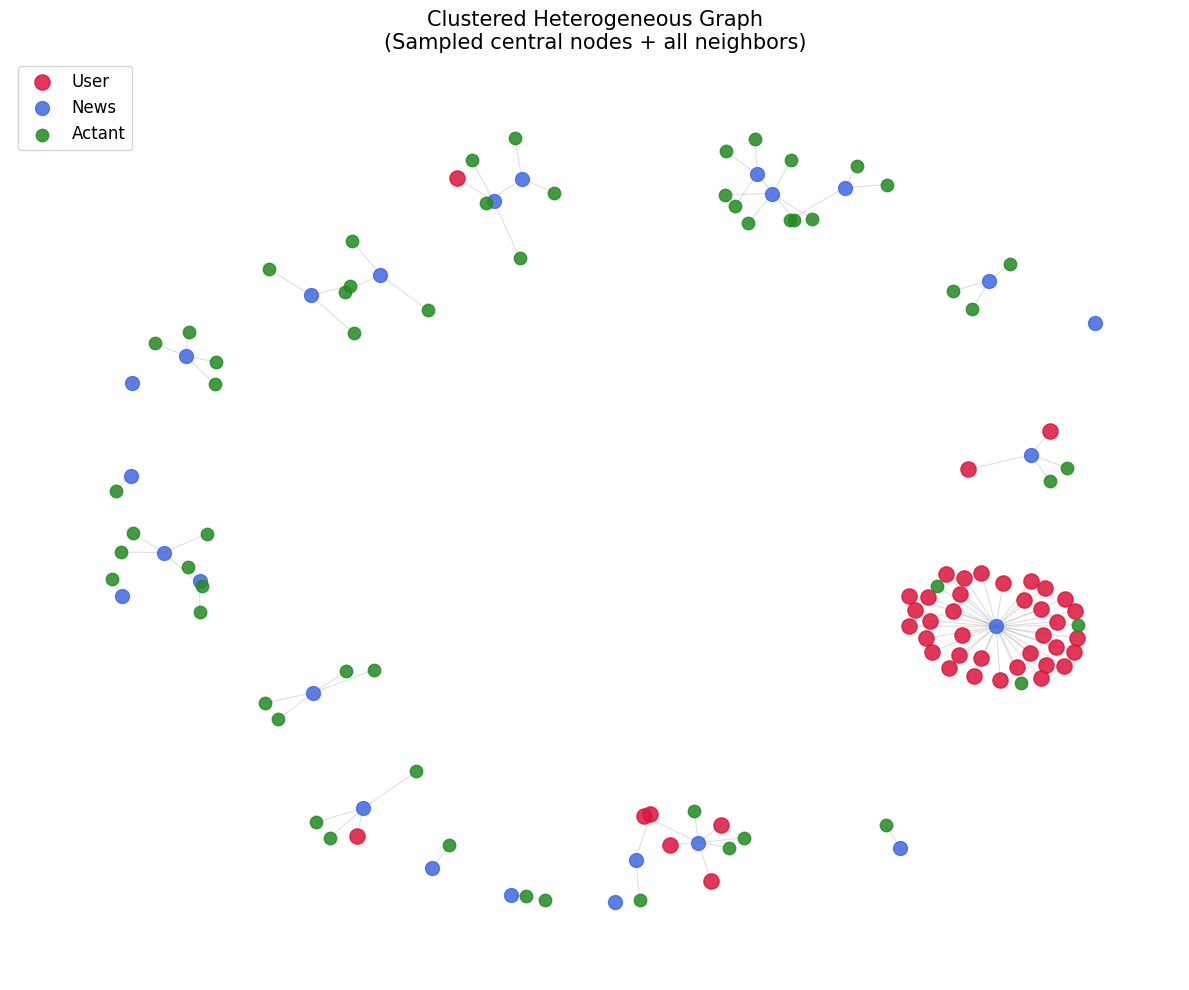

Nodes: 126, Edges: 101
Node type counts: {'user': 44, 'news': 25, 'actant': 57}


In [21]:
visualize_hetero_clustered(hetero_graph, sample_central_type='news', sample_size=25)

#  3: HeteroGAT

In [22]:
import torch

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Using device: cuda
GPU: NVIDIA L40S
Memory: 44.4 GB


## 3.1: Class Code

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, GATConv, Linear

class HeteroGAT(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=64, num_layers=2, num_heads=4, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.input_proj = nn.ModuleDict({
            'user': Linear(input_dim, hidden_dim),
            'news': Linear(input_dim, hidden_dim), 
            'actant': Linear(input_dim, hidden_dim)
        })
        self.edge_types = [
            ('user', 'clicks', 'news'),
            ('news', 'clicked_by', 'user'),
            ('news', 'has', 'actant'),
            ('actant', 'appears_in', 'news'),
            ('actant', 'cooccurs_with', 'actant'),   
            ('actant', 'coclicked_with', 'actant')  
        ]
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            conv_dict = {}
            for edge_type in self.edge_types:
                conv_dict[edge_type] = GATConv(
                    in_channels=hidden_dim,
                    out_channels=hidden_dim // num_heads,
                    heads=num_heads,
                    dropout=dropout,
                    concat=True,
                    add_self_loops=False
                )
            self.convs.append(HeteroConv(conv_dict, aggr='sum'))
        self.dropout = nn.Dropout(dropout)

    def forward(self, data):
        x_dict = data.x_dict
        edge_index_dict = data.edge_index_dict
        h_dict = {nt: self.input_proj[nt](x) for nt, x in x_dict.items() if nt in self.input_proj}
        for i, conv in enumerate(self.convs):
            filtered_edges = {
                et: ei for et, ei in edge_index_dict.items()
                if et in self.edge_types and ei.shape[1] > 0 and et[0] in h_dict and et[2] in h_dict
            }
            if not filtered_edges:
                break
            h_dict = conv(h_dict, filtered_edges)
            if i < len(self.convs) - 1:
                h_dict = {k: F.relu(v) for k, v in h_dict.items()}
                h_dict = {k: self.dropout(v) for k, v in h_dict.items()}
        return h_dict


##  3.2: BPR loss code

In [25]:
# Create validation triplets
import random
from collections import defaultdict
import os

def create_bpr_training_data(behaviors_df, user_to_id, news_to_id, split='train', neg_ratio=1, seed=42):
    """
    Vectorized creation of BPR training triplets from behaviors DataFrame.
    Returns a numpy array of shape (n_triplets, 3): (user_idx, pos_item_idx, neg_item_idx)
    """
    np.random.seed(seed)
    split_df = behaviors_df[behaviors_df['split'] == split].copy()
    
    # Flatten impressions into a DataFrame
    records = []
    for i, row in split_df.iterrows():
        user_id = row['user_id']
        if user_id not in user_to_id:
            continue
        user_idx = user_to_id[user_id]
        for news_id, label in row['impressions']:
            if news_id in news_to_id:
                news_idx = news_to_id[news_id]
                records.append((user_idx, news_idx, label))
    
    df = pd.DataFrame(records, columns=['user', 'news', 'label'])
    
    # Get positive and negative sets for each user
    user_pos = df[df['label']==1].groupby('user')['news'].apply(set).to_dict()
    user_neg = df[df['label']==0].groupby('user')['news'].apply(set).to_dict()
    all_news = np.arange(len(news_to_id))
    
    triplets = []
    for user, pos_items in user_pos.items():
        neg_candidates = np.array(list(user_neg.get(user, set()) | (set(all_news) - pos_items)))
        pos_items_arr = np.array(list(pos_items))
        if len(neg_candidates) == 0:
            continue  # skip if user has no negatives
        for pos_item in pos_items_arr:
            # Vectorized negative sampling: fast, can repeat for neg_ratio
            neg_samples = np.random.choice(neg_candidates, size=neg_ratio, replace=(len(neg_candidates)<neg_ratio))
            for neg_item in neg_samples:
                triplets.append((user, pos_item, neg_item))
    
    print(f"Created {len(triplets)} triplets for {split} (vectorized)")
    return np.array(triplets, dtype=np.int32)
    return triplets

def load_or_create_bpr_triplets(behaviors_df, user_to_id, news_to_id, split, neg_ratio=1, seed=42):
    out_dir = 'data/bpr_loss_triplets'
    os.makedirs(out_dir, exist_ok=True)
    out_path = f"{out_dir}/{split}_triplets.npy"
    
    if os.path.exists(out_path):
        print(f"Loading cached {split} triplets from {out_path}")
        triplets = np.load(out_path)
        return triplets
    
    print(f"No cache for {split} triplets. Calculating...")
    triplets = create_bpr_training_data(behaviors_df, user_to_id, news_to_id, split, neg_ratio, seed)
    np.save(out_path, triplets)
    print(f"Saved {split} triplets to {out_path}")
    return triplets

# Usage:
train_triplets = load_or_create_bpr_triplets(behaviors_df, user_to_id, news_to_id, 'train', neg_ratio=1)
val_triplets = load_or_create_bpr_triplets(behaviors_df, user_to_id, news_to_id, 'val', neg_ratio=1)

Loading cached train triplets from data/bpr_loss_triplets/train_triplets.npy
Loading cached val triplets from data/bpr_loss_triplets/val_triplets.npy


In [26]:
train_triplets[0]

array([    0, 11153,  2449], dtype=int32)

What Each Triplet Means: `(user_123, news_456, news_789)` means:
* User 123 clicked on News 456 (positive interaction)
* User 123 did NOT click on News 789 (negative interaction)
* Training signal: User 123 prefers News 456 over News 789
* During training, the loss function tries to maximize: `sigmoid(score(user_123, news_456) - score(user_123, news_789))`
* So have two types of negative samples: 1. Explicit negatives (users saw but did not click) and 2. Implicit Negatives (users never saw)

This approach was adopted as an improvement of random negative sampling that we saw in an implementation.

In [27]:
def compute_bpr_loss(model, triplets, graph_data, device):
    model.eval()
    users = torch.tensor([t[0] for t in triplets], dtype=torch.long, device=device)
    pos_items = torch.tensor([t[1] for t in triplets], dtype=torch.long, device=device)
    neg_items = torch.tensor([t[2] for t in triplets], dtype=torch.long, device=device)
    with torch.no_grad():
        h_dict = model(graph_data.to(device))
        user_emb = h_dict['user']
        news_emb = h_dict['news']
        batch_user_emb = user_emb[users]
        batch_pos_emb = news_emb[pos_items]
        batch_neg_emb = news_emb[neg_items]
        loss = bpr_loss(batch_user_emb, batch_pos_emb, batch_neg_emb)
    return loss.item()

## 3.3: Training Loop


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

def create_data_loader(triplets, batch_size=1024):
    users = torch.tensor([t[0] for t in triplets], dtype=torch.long)
    pos_items = torch.tensor([t[1] for t in triplets], dtype=torch.long)
    neg_items = torch.tensor([t[2] for t in triplets], dtype=torch.long)
    dataset = TensorDataset(users, pos_items, neg_items)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

def bpr_loss(user_emb, pos_emb, neg_emb):
    pos_scores = (user_emb * pos_emb).sum(dim=1)
    neg_scores = (user_emb * neg_emb).sum(dim=1)
    loss = -torch.log(torch.sigmoid(pos_scores - neg_scores)).mean()
    return loss

def train_epoch(model, train_loader, optimizer, graph_data, device):
    model.train()
    total_loss = 0
    num_batches = 0
    for users, pos_items, neg_items in train_loader:
        users, pos_items, neg_items = users.to(device), pos_items.to(device), neg_items.to(device)
        optimizer.zero_grad()
        h_dict = model(graph_data.to(device))
        user_emb = h_dict['user']
        news_emb = h_dict['news']
        batch_user_emb = user_emb[users]
        batch_pos_emb = news_emb[pos_items]
        batch_neg_emb = news_emb[neg_items]
        loss = bpr_loss(batch_user_emb, batch_pos_emb, batch_neg_emb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        num_batches += 1
    return total_loss / num_batches

def validate(model, val_loader, graph_data, device):
    model.eval()
    total_loss = 0
    num_batches = 0
    with torch.no_grad():
        for users, pos_items, neg_items in val_loader:
            users, pos_items, neg_items = users.to(device), pos_items.to(device), neg_items.to(device)
            h_dict = model(graph_data.to(device))
            user_emb = h_dict['user']
            news_emb = h_dict['news']
            batch_user_emb = user_emb[users]
            batch_pos_emb = news_emb[pos_items]
            batch_neg_emb = news_emb[neg_items]
            loss = bpr_loss(batch_user_emb, batch_pos_emb, batch_neg_emb)
            total_loss += loss.item()
            num_batches += 1
    return total_loss / num_batches

def train_model(model, train_triplets, val_triplets, graph_data, 
                epochs=50, lr=0.001, weight_decay=1e-4, patience=5, batch_size=1024):
    device = next(model.parameters()).device
    graph_data = graph_data.to(device)
    train_loader = create_data_loader(train_triplets, batch_size=batch_size)
    val_loader = create_data_loader(val_triplets, batch_size=batch_size)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    train_losses = []
    val_losses = []

    print(f"Starting training for {epochs} epochs...")
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, optimizer, graph_data, device)
        val_loss = validate(model, val_loader, graph_data, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1:2d}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"         → New best validation loss!")
        else:
            patience_counter += 1
            print(f"         → No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Loaded best model (val loss: {best_val_loss:.4f})")

    return train_losses, val_losses

def plot_training_curves(train_losses, val_losses, title="Training Curves"):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', marker='o', markersize=3)
    plt.plot(val_losses, label='Val Loss', marker='s', markersize=3)
    plt.xlabel('Epoch')
    plt.ylabel('BPR Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    print(f"Final - Train: {train_losses[-1]:.4f}, Val: {val_losses[-1]:.4f}")

Starting training for 30 epochs...
Epoch  1: Train Loss: 0.0701, Val Loss: 0.0436
         → New best validation loss!
Epoch  2: Train Loss: 0.0347, Val Loss: 0.0372
         → New best validation loss!
Epoch  3: Train Loss: 0.0315, Val Loss: 0.0438
         → No improvement (1/5)
Epoch  4: Train Loss: 0.0292, Val Loss: 0.0390
         → No improvement (2/5)
Epoch  5: Train Loss: 0.0269, Val Loss: 0.0387
         → No improvement (3/5)
Epoch  6: Train Loss: 0.0262, Val Loss: 0.0384
         → No improvement (4/5)
Epoch  7: Train Loss: 0.0245, Val Loss: 0.0385
         → No improvement (5/5)
Early stopping triggered after 7 epochs
Loaded best model (val loss: 0.0372)


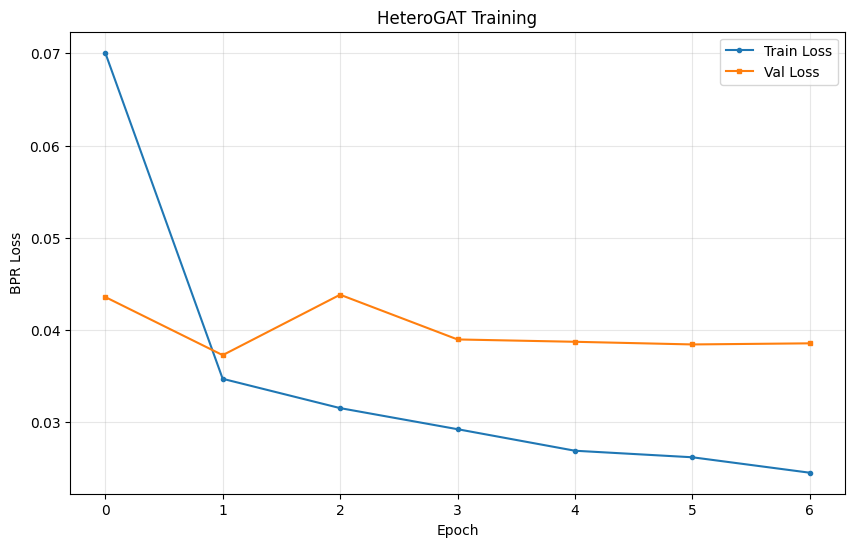

Final - Train: 0.0245, Val: 0.0385


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create the model
model_hetero_gat = HeteroGAT(
    input_dim=128,   # needs adjusting if we change node feature dim later
    hidden_dim=64,
    num_layers=2,
    num_heads=4,
    dropout=0.1
)

model_hetero_gat = model_hetero_gat.to(device)

# Train
train_losses, val_losses = train_model(
    model=model_hetero_gat,           
    train_triplets=train_triplets,
    val_triplets=val_triplets,
    graph_data=hetero_graph,
    epochs=30,
    lr=0.0005,
    weight_decay=1e-4,
    patience=5
)

# Plot curves
plot_training_curves(train_losses, val_losses, "HeteroGAT Training")

## 3.4: Visualize embeddings 

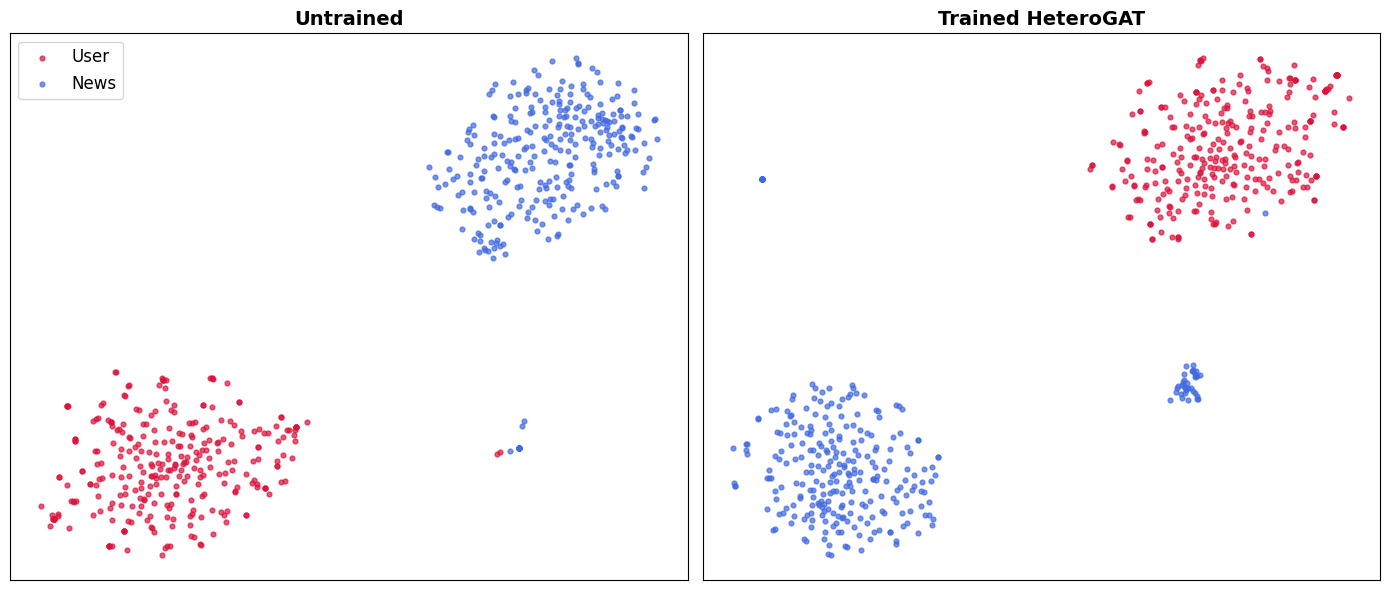

In [30]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np
import torch

# Sample users and news
num_users = len(user_to_id)
num_news = len(news_to_id)
sample_users = min(300, num_users)
sample_news = min(300, num_news)

user_indices = np.random.choice(num_users, size=sample_users, replace=False)
news_indices = np.random.choice(num_news, size=sample_news, replace=False)

# Create a fresh (untrained) HeteroGAT with the same config
fresh_model = HeteroGAT(
    input_dim=128,   # match your feature size!
    hidden_dim=64,
    num_layers=2,
    num_heads=4,
    dropout=0.1
).to(device)
fresh_model.eval()

# Prepare models to compare
models = [
    ("Untrained", fresh_model),
    ("Trained HeteroGAT", model_hetero_gat)
]

embeddings_list = []
for model_name, model in models:
    model.eval()
    with torch.no_grad():
        h_dict = model(hetero_graph.to(device))
        user_emb = h_dict['user'].cpu().numpy()  # [num_users, hidden_dim]
        news_emb = h_dict['news'].cpu().numpy()  # [num_news, hidden_dim]
        # Stack sampled users and news
        emb = np.vstack([
            user_emb[user_indices],       # shape [sample_users, hidden_dim]
            news_emb[news_indices]        # shape [sample_news, hidden_dim]
        ])
        embeddings_list.append(emb)

# Stack all for joint PCA/t-SNE
all_embeddings = np.vstack(embeddings_list)
pca = PCA(n_components=32, random_state=42)
all_embeddings_pca = pca.fit_transform(all_embeddings)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, metric='cosine')
tsne_all = tsne.fit_transform(all_embeddings_pca)

split_points = np.cumsum([emb.shape[0] for emb in embeddings_list])
tsne_embeddings = np.split(tsne_all, split_points[:-1])

# Plot (1 row, N columns)
fig, axes = plt.subplots(1, len(models), figsize=(7*len(models), 6))
if len(models) == 1:
    axes = [axes]

for idx, ax in enumerate(axes):
    ax.scatter(tsne_embeddings[idx][:sample_users, 0], tsne_embeddings[idx][:sample_users, 1],
               c='crimson', label='User', alpha=0.7, s=12)
    ax.scatter(tsne_embeddings[idx][sample_users:, 0], tsne_embeddings[idx][sample_users:, 1],
               c='royalblue', label='News', alpha=0.7, s=12)
    ax.set_title(models[idx][0], fontsize=14, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    if idx == 0:
        ax.legend(loc='best', fontsize=12)
plt.tight_layout()
plt.show()

=== Embedding Quality Comparison ===
Model              | User-User       | News-News       | Pos             | Neg             | Improve  
------------------------------------------------------------------------------------------
Untrained (fresh)  | 1.988±0.672 | 1.983±0.653 | 2.711±0.623 | 2.397±0.590 | -0.314
HeteroGAT          | 1.915±0.597 | 2.618±1.955 | 7.160±1.160 | 3.070±1.043 | -4.090


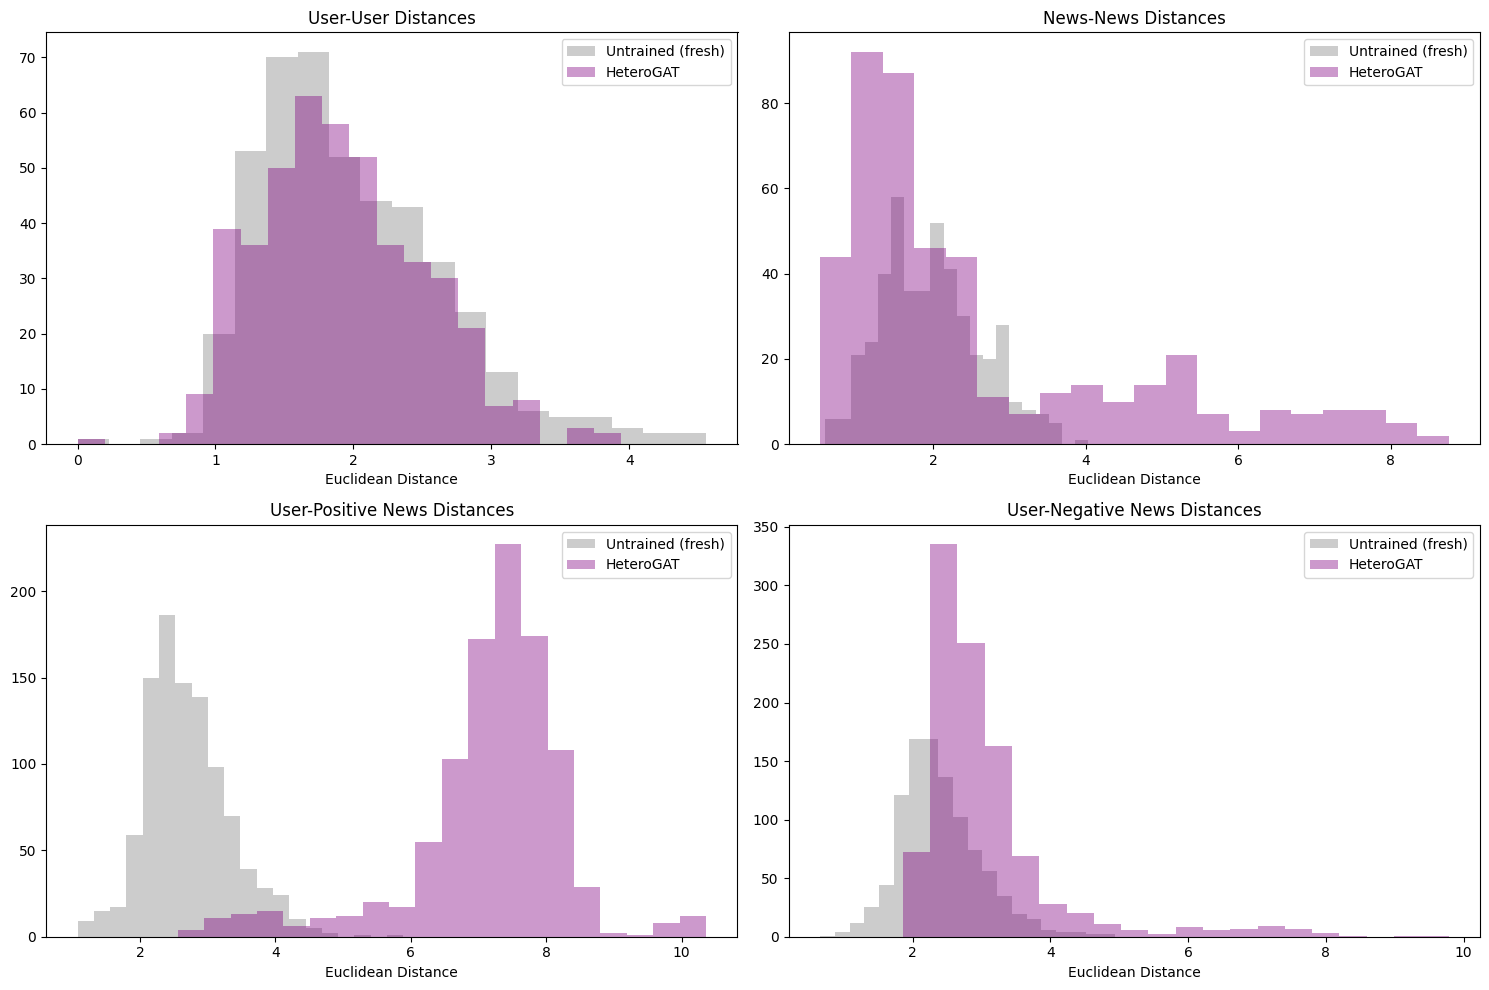

/tmp/ipykernel_1497080/4014013196.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=box_labels, patch_artist=True)


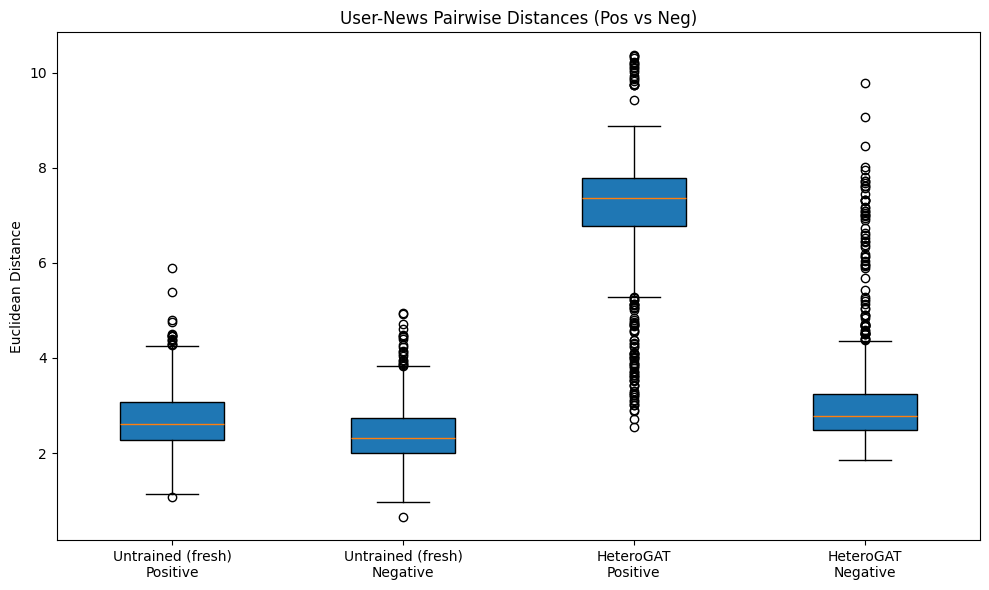

In [31]:
## Checking Embedding Quality

import matplotlib.pyplot as plt
import numpy as np
import random

def analyze_embedding_quality_multi_hetero(models, model_names, hetero_graph_data, train_triplets, sample_size=1000, device='cpu'):
    """Compare embedding quality for user-user and news-news distances, for HeteroGAT models"""

    results = []
    plot_data = {'user_dists': [], 'news_dists': [], 'pos_pairs': [], 'neg_pairs': []}

    for model in models:
        model.eval()
        with torch.no_grad():
            h_dict = model(hetero_graph_data.to(device))
            user_emb = h_dict['user'].cpu()
            news_emb = h_dict['news'].cpu()

        # Sampling
        sample_users = min(sample_size // 2, user_emb.shape[0])
        sample_news = min(sample_size // 2, news_emb.shape[0])
        user_sample = user_emb[:sample_users].numpy()
        news_sample = news_emb[:sample_news].numpy()

        # User-user distances (within sample)
        user_dists = []
        for i in range(0, len(user_sample), 10):
            for j in range(i+1, min(i+10, len(user_sample))):
                dist = np.linalg.norm(user_sample[i] - user_sample[j])
                user_dists.append(dist)

        # News-news distances (within sample)
        news_dists = []
        for i in range(0, len(news_sample), 10):
            for j in range(i+1, min(i+10, len(news_sample))):
                dist = np.linalg.norm(news_sample[i] - news_sample[j])
                news_dists.append(dist)

        # User-news distances (positive vs negative pairs)
        pos_pairs = []
        neg_pairs = []
        sample_triplets = random.sample(list(train_triplets), min(1000, len(train_triplets)))

        for user_idx, pos_news, neg_news in sample_triplets:
            if user_idx < user_emb.shape[0] and pos_news < news_emb.shape[0] and neg_news < news_emb.shape[0]:
                user_vec = user_emb[user_idx].numpy()
                pos_vec = news_emb[pos_news].numpy()
                neg_vec = news_emb[neg_news].numpy()
                pos_dist = np.linalg.norm(user_vec - pos_vec)
                neg_dist = np.linalg.norm(user_vec - neg_vec)
                pos_pairs.append(pos_dist)
                neg_pairs.append(neg_dist)

        # Store stats for reporting
        result = {
            'user_mean': np.mean(user_dists),
            'user_std': np.std(user_dists),
            'news_mean': np.mean(news_dists),
            'news_std': np.std(news_dists),
            'pos_mean': np.mean(pos_pairs),
            'pos_std': np.std(pos_pairs),
            'neg_mean': np.mean(neg_pairs),
            'neg_std': np.std(neg_pairs),
            'improvement': np.mean(neg_pairs) - np.mean(pos_pairs),
        }
        results.append(result)
        plot_data['user_dists'].append(user_dists)
        plot_data['news_dists'].append(news_dists)
        plot_data['pos_pairs'].append(pos_pairs)
        plot_data['neg_pairs'].append(neg_pairs)

    # Print comparison table
    print("=== Embedding Quality Comparison ===")
    print(f"{'Model':<18} | {'User-User':<15} | {'News-News':<15} | {'Pos':<15} | {'Neg':<15} | {'Improve':<9}")
    print("-"*90)
    for i, name in enumerate(model_names):
        r = results[i]
        print(f"{name:<18} | {r['user_mean']:.3f}±{r['user_std']:.3f} | {r['news_mean']:.3f}±{r['news_std']:.3f} | "
              f"{r['pos_mean']:.3f}±{r['pos_std']:.3f} | {r['neg_mean']:.3f}±{r['neg_std']:.3f} | {r['improvement']:.3f}")

    # Overlayed plots for direct comparison
    colors = ['gray', 'purple', 'forestgreen', 'orange', 'red', 'blue']  # extend as needed

    plt.figure(figsize=(15, 10))
    plt.subplot(2, 2, 1)
    for i, name in enumerate(model_names):
        plt.hist(plot_data['user_dists'][i], bins=20, alpha=0.4, label=f'{name}', color=colors[i % len(colors)])
    plt.title('User-User Distances')
    plt.xlabel('Euclidean Distance')
    plt.legend()

    plt.subplot(2, 2, 2)
    for i, name in enumerate(model_names):
        plt.hist(plot_data['news_dists'][i], bins=20, alpha=0.4, label=f'{name}', color=colors[i % len(colors)])
    plt.title('News-News Distances')
    plt.xlabel('Euclidean Distance')
    plt.legend()

    plt.subplot(2, 2, 3)
    for i, name in enumerate(model_names):
        plt.hist(plot_data['pos_pairs'][i], bins=20, alpha=0.4, label=f'{name}', color=colors[i % len(colors)])
    plt.title('User-Positive News Distances')
    plt.xlabel('Euclidean Distance')
    plt.legend()

    plt.subplot(2, 2, 4)
    for i, name in enumerate(model_names):
        plt.hist(plot_data['neg_pairs'][i], bins=20, alpha=0.4, label=f'{name}', color=colors[i % len(colors)])
    plt.title('User-Negative News Distances')
    plt.xlabel('Euclidean Distance')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Boxplot for positive vs negative pairs across models
    plt.figure(figsize=(10, 6))
    box_data = []
    box_labels = []
    for i, name in enumerate(model_names):
        box_data.append(plot_data['pos_pairs'][i])
        box_labels.append(f"{name}\nPositive")
        box_data.append(plot_data['neg_pairs'][i])
        box_labels.append(f"{name}\nNegative")
    plt.boxplot(box_data, labels=box_labels, patch_artist=True)
    plt.title('User-News Pairwise Distances (Pos vs Neg)')
    plt.ylabel('Euclidean Distance')
    plt.tight_layout()
    plt.show()

# Example usage:
models_list = [fresh_model, model_hetero_gat]
model_names = ["Untrained (fresh)", "HeteroGAT"]
analyze_embedding_quality_multi_hetero(
    models=models_list,
    model_names=model_names,
    hetero_graph_data=hetero_graph,
    train_triplets=train_triplets,
    sample_size=1000,
    device=device
)

# 4: Evaluation Study

## 4.1: Evaluation on Test Set

In [32]:
# Create test data for evaluation
def create_test_data(behaviors_df, user_to_id, news_to_id, split='dev'):
    """Create test data with user-item interactions"""
    split_data = behaviors_df[behaviors_df['split'] == split]
    
    user_test_items = defaultdict(list)  # positive test items per user
    
    for _, row in split_data.iterrows():
        user_id = row['user_id']
        if user_id not in user_to_id:
            continue
        user_idx = user_to_id[user_id]
        
        for news_id, label in row['impressions']:
            if news_id in news_to_id and label == 1:  # Only positive items
                news_idx = news_to_id[news_id]
                user_test_items[user_idx].append(news_idx)
    
    print(f"Test users with positive items: {len(user_test_items)}")
    print(f"Avg test items per user: {np.mean([len(items) for items in user_test_items.values()]):.2f}")
    return user_test_items

# Create test data
test_data = create_test_data(behaviors_df, user_to_id, news_to_id, 'test')

Test users with positive items: 19099
Avg test items per user: 1.81


In [33]:
# Print one element from test_data
user, news_list = next(iter(test_data.items()))
print(f"user: {user}")
print(f"test news indices: {news_list}")

user: 47225
test news indices: [16447]


## 4.2: Build Test Graph

In [34]:
import torch
from torch_geometric.data import HeteroData

def build_test_heterodata(train_hetero_graph, behaviors_df, user_to_id, news_to_id, split='test'):
    """
    Build HeteroData for evaluation (add test split edges to train graph)
    """
    print("Building test-time HeteroData...")
    data = train_hetero_graph.clone()
    
    test_split = behaviors_df[behaviors_df['split'] == split]
    user_news_src = []
    user_news_dst = []
    news_user_src = []
    news_user_dst = []
    
    for _, row in test_split.iterrows():
        if row['user_id'] not in user_to_id:
            continue
        u_idx = user_to_id[row['user_id']]
        for n_id, _ in row['impressions']:  # add all impressions
            if n_id in news_to_id:
                n_idx = news_to_id[n_id]
                user_news_src.append(u_idx)
                user_news_dst.append(n_idx)
                news_user_src.append(n_idx)
                news_user_dst.append(u_idx)
    
    # Add new test edges to existing train edges
    old_un_ei = data['user', 'clicks', 'news'].edge_index
    old_nu_ei = data['news', 'clicked_by', 'user'].edge_index
    new_un_ei = torch.tensor([user_news_src, user_news_dst], dtype=torch.long, device=old_un_ei.device)
    new_nu_ei = torch.tensor([news_user_src, news_user_dst], dtype=torch.long, device=old_nu_ei.device)
    # Concat (with old)
    data['user', 'clicks', 'news'].edge_index = torch.cat([old_un_ei, new_un_ei], dim=1)
    data['news', 'clicked_by', 'user'].edge_index = torch.cat([old_nu_ei, new_nu_ei], dim=1)
    print(f"Added {new_un_ei.shape[1]} new test user-news edges.")
    return data

import numpy as np

def create_proper_test_data(behaviors_df, user_to_id, news_to_id, split='test'):
    """
    Create test data properly - separating what we evaluate vs what we use for embedding
    Returns:
        user_test_items: {user_idx: [positive_news_indices]} (only positives for evaluation)
        user_all_items: {user_idx: [(news_idx, label), ...]} (all impressions for each user)
    """
    split_data = behaviors_df[behaviors_df['split'] == split]
    
    user_test_items = {}  # Only positive items (what we want to predict/evaluate)
    user_all_items = {}   # All user interactions in the split (for ranking computation)
    
    for _, row in split_data.iterrows():
        user_id = row['user_id']
        if user_id not in user_to_id:
            continue
        user_idx = user_to_id[user_id]
        
        test_positives = []
        all_interactions = []
        
        for news_id, label in row['impressions']:
            if news_id in news_to_id:
                news_idx = news_to_id[news_id]
                all_interactions.append((news_idx, label))
                if label == 1:
                    test_positives.append(news_idx)
        
        if test_positives:  # Only keep users with at least one positive (clicked) news
            user_test_items[user_idx] = test_positives
            user_all_items[user_idx] = all_interactions
    
    print(f"Proper test data: {len(user_test_items)} users with positive items")
    print(f"Avg positive items per user: {np.mean([len(items) for items in user_test_items.values()]):.2f}")
    return user_test_items, user_all_items


## 4.3: Evaluate Model on Test Graph

In [35]:
import numpy as np

import numpy as np
from sklearn.metrics import roc_auc_score

def evaluate_hetero_model(
    model, test_hetero_graph, test_data, test_all_items, k_values=[5, 10, 20], device="cpu"
):
    model.eval()
    with torch.no_grad():
        h_dict = model(test_hetero_graph.to(device))
        user_emb = h_dict['user']
        news_emb = h_dict['news']
    
    def dcg_at_k(relevances, k):
        relevances = np.array(relevances)[:k]
        if len(relevances) == 0:
            return 0.0
        return np.sum(relevances / np.log2(np.arange(2, len(relevances) + 2)))
    
    def ndcg_at_k(relevances, k):
        dcg = dcg_at_k(relevances, k)
        ideal_relevances = sorted(relevances, reverse=True)
        idcg = dcg_at_k(ideal_relevances, k)
        return dcg / idcg if idcg > 0 else 0.0

    def reciprocal_rank(relevances):
        for i, rel in enumerate(relevances):
            if rel > 0:
                return 1.0 / (i + 1)
        return 0.0

    all_precisions = {k: [] for k in k_values}
    all_recalls = {k: [] for k in k_values}
    all_ndcgs = {k: [] for k in k_values}
    all_mrrs = []
    all_scores = []
    all_labels = []
    valid_users = 0
    
    for user_idx, test_items in test_data.items():
        if user_idx not in test_all_items or len(test_items) == 0:
            continue
        impression = test_all_items[user_idx]
        impression_news = [news_idx for news_idx, _ in impression]
        impression_labels = [label for _, label in impression]
        if len(impression_news) == 0:
            continue
        valid_users += 1

        user_vec = user_emb[user_idx]
        news_vecs = news_emb[impression_news]
        sims = torch.cosine_similarity(user_vec.unsqueeze(0), news_vecs).cpu().numpy()
        sorted_idx = np.argsort(-sims)
        ranked_labels = np.array(impression_labels)[sorted_idx]

        hits_k = lambda k: ranked_labels[:k].sum()
        n_rel = (np.array(impression_labels) == 1).sum()
        n_rel = max(1, n_rel)  # avoid div by zero

        for k in k_values:
            all_precisions[k].append(hits_k(k) / k)
            all_recalls[k].append(hits_k(k) / n_rel)
            all_ndcgs[k].append(ndcg_at_k(ranked_labels, k))
        all_mrrs.append(reciprocal_rank(ranked_labels))

        # For AUC (use original scores/labels)
        all_scores.extend(list(sims))
        all_labels.extend(list(impression_labels))

    results = {}
    results['valid_users'] = valid_users
    results['mrr'] = np.mean(all_mrrs) if all_mrrs else 0.0
    # Add AUC!
    if len(set(all_labels)) > 1:
        try:
            results['auc'] = roc_auc_score(all_labels, all_scores)
        except Exception:
            results['auc'] = 0.0
    else:
        results['auc'] = 0.0
    for k in k_values:
        results[f'precision@{k}'] = np.mean(all_precisions[k]) if all_precisions[k] else 0.0
        results[f'recall@{k}'] = np.mean(all_recalls[k]) if all_recalls[k] else 0.0
        results[f'ndcg@{k}'] = np.mean(all_ndcgs[k]) if all_ndcgs[k] else 0.0
    return results


def print_gat_metrics(results, model_name):
    print(f"\n{model_name} Model Evaluation Metrics")
    print(f"Users Evaluated: {results.get('valid_users', 'N/A')}")
    print()
    print("{:<12} {:>12} {:>12} {:>12}".format("Metric", "@5", "@10", "@20"))
    print("-" * 52)
    for metric in ["precision", "recall", "ndcg"]:
        row = [metric.capitalize()]
        for k in [5, 10, 20]:
            value = results.get(f"{metric}@{k}", None)
            row.append(f"{value:.5f}" if value is not None else "N/A")
        print("{:<12} {:>12} {:>12} {:>12}".format(*row))
    print()
    mrr_val = results.get('mrr', 'N/A')
    print(f"MRR:  {mrr_val:.4f}" if isinstance(mrr_val, (float, int)) else f"MRR:  {mrr_val}")
    auc_val = results.get('auc', 'N/A')
    print(f"AUC:  {auc_val:.4f}" if isinstance(auc_val, (float, int)) else f"AUC:  {auc_val}")

In [36]:
test_hetero_graph = build_test_heterodata(
    train_hetero_graph=hetero_graph,
    behaviors_df=behaviors_df,
    user_to_id=user_to_id,
    news_to_id=news_to_id,
    split='test'
)

# create test_data_proper and test_all_items for the test split
test_data_proper, test_all_items = create_proper_test_data(
    behaviors_df, 
    user_to_id, 
    news_to_id, 
    split='test'
)


# Evaluate
results = evaluate_hetero_model(
    model=model_hetero_gat,
    test_hetero_graph=test_hetero_graph,
    test_data=test_data_proper,
    test_all_items=test_all_items,
    k_values=[5, 10, 20],
    device=device
)

Building test-time HeteroData...
Added 885934 new test user-news edges.
Proper test data: 19099 users with positive items
Avg positive items per user: 1.50


In [37]:
print_gat_metrics(results, 'HeteroGAT')


HeteroGAT Model Evaluation Metrics
Users Evaluated: 19099

Metric                 @5          @10          @20
----------------------------------------------------
Precision         0.08107      0.06388      0.04498
Recall            0.33701      0.51812      0.69212
Ndcg              0.23150      0.29268      0.34122

MRR:  0.2599
AUC:  0.4394


**Interpretation:** We can see that without any semantic information (category, actant-role semantics) we could already outperform our best bipartite GAT that enriched the news node with category, actant embeddings, and temporal information as node features. So we then proceed to enrich the nws and actants with features.

# 5: Enriching Nodes with Features

## 5.1: Modify `HeteroGAT` class for node features

* News: category embedding (16-dim) + base features (64-dim) = 80-dim total
* Actants: one-hot roles (6-dim) + base features (32-dim) = 38-dim total
* Users: keep 128-dim random for now

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, GATConv, Linear

class HeteroGAT(nn.Module):
    def __init__(self, 
                 input_dims={'user': 128, 'news': 80, 'actant': 38}, 
                 hidden_dim=64, 
                 num_layers=2, 
                 num_heads=4, 
                 dropout=0.1):
        """
        HeteroGAT with different input dimensions per node type
        
        Args:
            input_dims: Dict with input dimensions per node type
                       e.g., {'user': 128, 'news': 80, 'actant': 38}
            hidden_dim: Hidden dimension for all node types after projection
            num_layers: Number of GAT layers
            num_heads: Number of attention heads per layer
            dropout: Dropout rate
        """
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.input_dims = input_dims
        
        # Different input projections for each node type
        self.input_proj = nn.ModuleDict()
        for node_type, input_dim in input_dims.items():
            self.input_proj[node_type] = Linear(input_dim, hidden_dim)
        
        # Define all edge types in the heterogeneous graph
        self.edge_types = [
            ('user', 'clicks', 'news'),
            ('news', 'clicked_by', 'user'),
            ('news', 'has', 'actant'),
            ('actant', 'appears_in', 'news'),
            ('actant', 'cooccurs_with', 'actant'),  # Actant co-occurrence
            ('actant', 'coclicked_with', 'actant')   # Actant co-click
        ]
        
        # GAT layers with heterogeneous convolutions
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            conv_dict = {}
            for edge_type in self.edge_types:
                conv_dict[edge_type] = GATConv(
                    in_channels=hidden_dim,
                    out_channels=hidden_dim // num_heads,
                    heads=num_heads,
                    dropout=dropout,
                    concat=True,
                    add_self_loops=False
                )
            self.convs.append(HeteroConv(conv_dict, aggr='sum'))
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, data):
        """
        Forward pass through HeteroGAT
        
        Args:
            data: HeteroData object with x_dict and edge_index_dict
            
        Returns:
            h_dict: Dictionary of node embeddings per type
        """
        x_dict = data.x_dict
        edge_index_dict = data.edge_index_dict
        
        # Project each node type to hidden dimension
        h_dict = {}
        for node_type, x in x_dict.items():
            if node_type in self.input_proj:
                h_dict[node_type] = self.input_proj[node_type](x)
            else:
                print(f"Warning: No projection layer for node type {node_type}")
        
        # Apply GAT layers
        for i, conv in enumerate(self.convs):
            # Filter edges to only include those with valid node types and non-empty edges
            filtered_edges = {
                et: ei for et, ei in edge_index_dict.items()
                if (et in self.edge_types and 
                    ei.shape[1] > 0 and 
                    et[0] in h_dict and 
                    et[2] in h_dict)
            }
            
            if not filtered_edges:
                print(f"Warning: No valid edges found at layer {i}")
                break
            
            # Apply heterogeneous convolution
            h_dict = conv(h_dict, filtered_edges)
            
            # Apply activation and dropout (except for last layer)
            if i < len(self.convs) - 1:
                h_dict = {k: F.relu(v) for k, v in h_dict.items()}
                h_dict = {k: self.dropout(v) for k, v in h_dict.items()}
        
        return h_dict

## 5.2: Feature Extraction for News node

the feature extraction function for news nodes with category embeddings and base features:
* Category Mapping: Extracts all unique categories and creates mapping
* Learnable Embeddings: Uses nn.Embedding for category features (not just one-hot)
* Concatenated Features: Combines category embeddings (16-dim) + base features (64-dim) = 80-dim total

In [39]:
import torch
import torch.nn as nn

def create_news_features(news_to_id, news_dict, device='cuda', 
                        category_embed_dim=16, base_feature_dim=64):
    """
    Create enriched features for news nodes combining category embeddings and base features
    
    Args:
        news_to_id: Dict mapping news_id to node index
        news_dict: Dict containing news data with categories
        device: Device to place tensors on
        category_embed_dim: Dimension of category embeddings
        base_feature_dim: Dimension of base random features
        
    Returns:
        news_features: Tensor of shape [num_news, category_embed_dim + base_feature_dim]
        cat_to_id: Dict mapping category names to indices
        num_categories: Number of unique categories
    """
    num_news = len(news_to_id)
    
    # Extract and map categories
    print("Extracting news categories...")
    categories = sorted(set(news['category'] for news in news_dict.values()))
    cat_to_id = {cat: idx for idx, cat in enumerate(categories)}
    num_categories = len(categories)
    
    print(f"Found {num_categories} unique categories: {categories[:5]}..." if len(categories) > 5 else f"Found {num_categories} categories: {categories}")
    
    # Create category indices for each news
    news_category_indices = torch.zeros(num_news, dtype=torch.long, device=device)
    missing_categories = 0
    
    for news_id, news_idx in news_to_id.items():
        if news_id in news_dict:
            cat = news_dict[news_id]['category']
            news_category_indices[news_idx] = cat_to_id.get(cat, 0)  # 0 for unknown/missing
        else:
            missing_categories += 1
            news_category_indices[news_idx] = 0  # Default to first category
    
    if missing_categories > 0:
        print(f"Warning: {missing_categories} news articles not found in news_dict")
    
    # Create category embedding layer
    category_embedding = nn.Embedding(num_categories, category_embed_dim, padding_idx=None)
    category_embedding = category_embedding.to(device)
    
    # Initialize category embeddings with small random values
    nn.init.normal_(category_embedding.weight, std=0.1)
    
    # Get category embeddings for all news
    with torch.no_grad():
        news_category_features = category_embedding(news_category_indices)  # [num_news, category_embed_dim]
    
    # Create base features (random initialization for now)
    # these could be replaced with content-based features (BERT, TF-IDF, etc.), but we decided to keep it light for now
    news_base_features = torch.randn(num_news, base_feature_dim, device=device)
    nn.init.normal_(news_base_features, std=0.1)
    
    # Concatenate category embeddings and base features
    news_features = torch.cat([news_category_features, news_base_features], dim=1)
    # Final shape: [num_news, category_embed_dim + base_feature_dim] = [num_news, 16 + 64] = [num_news, 80]
    
    print(f"News features created:")
    print(f"  - Category embeddings: {news_category_features.shape} (dim={category_embed_dim})")
    print(f"  - Base features: {news_base_features.shape} (dim={base_feature_dim})")
    print(f"  - Combined features: {news_features.shape} (total_dim={category_embed_dim + base_feature_dim})")
    print(f"  - Category distribution sample: {torch.bincount(news_category_indices[:100])}")
    
    return news_features, cat_to_id, num_categories

## 5.3: Actant Node Feature

Greimas Role Encoding: One-hot encoding for the 6 canonical actant roles

In [40]:
import torch
import torch.nn as nn

def create_actant_features(actant_to_id, id_to_actant, device='cuda', 
                          base_feature_dim=32):
    """
    Create enriched features for actant nodes combining role one-hot encoding and base features
    
    Args:
        actant_to_id: Dict mapping (actant_text, role) tuples to node indices
        id_to_actant: Dict mapping node indices to (actant_text, role) tuples
        device: Device to place tensors on
        base_feature_dim: Dimension of base random features
        
    Returns:
        actant_features: Tensor of shape [num_actants, 6 + base_feature_dim]
        role_to_id: Dict mapping role names to indices
        role_distribution: Dict showing count of each role
    """
    num_actants = len(actant_to_id)
    
    # Step 1: Define Greimas actant roles
    greimas_roles = ['subject', 'object', 'sender', 'receiver', 'helper', 'opponent']
    role_to_id = {role: idx for idx, role in enumerate(greimas_roles)}
    role_dim = len(greimas_roles)  # 6 dimensions
    
    print(f"Creating actant features for {num_actants} actants...")
    print(f"Greimas roles: {greimas_roles}")
    
    # Step 2: Create role one-hot encodings
    actant_role_features = torch.zeros(num_actants, role_dim, device=device)
    role_distribution = {role: 0 for role in greimas_roles}
    unknown_roles = set()
    
    for actant_idx in range(num_actants):
        if actant_idx in id_to_actant:
            actant_text, role = id_to_actant[actant_idx]
            
            if role in role_to_id:
                # Set one-hot encoding for this role
                role_idx = role_to_id[role]
                actant_role_features[actant_idx, role_idx] = 1.0
                role_distribution[role] += 1
            else:
                # Handle unknown/missing roles - default to 'subject' (most common)
                unknown_roles.add(role)
                actant_role_features[actant_idx, role_to_id['subject']] = 1.0
                role_distribution['subject'] += 1
        else:
            print(f"Warning: No actant data found for index {actant_idx}")
            # Default to 'subject' role
            actant_role_features[actant_idx, role_to_id['subject']] = 1.0
            role_distribution['subject'] += 1
    
    if unknown_roles:
        print(f"Warning: Found {len(unknown_roles)} unknown roles: {unknown_roles}")
        print("These were mapped to 'subject' role")
    
    # Step 3: Create base features (random initialization for now)
    # TODO later: these could be replaced with entity embeddings (BERT, Word2Vec, etc.)
    actant_base_features = torch.randn(num_actants, base_feature_dim, device=device)
    nn.init.normal_(actant_base_features, std=0.1)
    
    # Step 4: Concatenate role one-hot and base features
    actant_features = torch.cat([actant_role_features, actant_base_features], dim=1)
    # Final shape: [num_actants, role_dim + base_feature_dim] = [num_actants, 6 + 32] = [num_actants, 38]
    
    # Step 5: Log statistics
    print(f"Actant features created:")
    print(f"  - Role one-hot features: {actant_role_features.shape} (dim={role_dim})")
    print(f"  - Base features: {actant_base_features.shape} (dim={base_feature_dim})")
    print(f"  - Combined features: {actant_features.shape} (total_dim={role_dim + base_feature_dim})")
    
    print(f"Role distribution:")
    for role, count in role_distribution.items():
        percentage = (count / num_actants) * 100
        print(f"  - {role}: {count:,} ({percentage:.1f}%)")
    
    # Step 6: Verify one-hot encoding correctness
    role_sums = actant_role_features.sum(dim=1)
    if not torch.allclose(role_sums, torch.ones_like(role_sums)):
        print("Warning: Some actants don't have exactly one role assigned!")
    else:
        print("✓ Role one-hot encoding verified - each actant has exactly one role")
    
    return actant_features, role_to_id, role_distribution

## 5.4: Builed Enriched Graph

In [41]:
def build_hetero_graph_enriched(user_to_id, news_to_id, actant_to_id, id_to_actant, 
                               behaviors_df, auxiliary_mappings, news_dict, device='cuda'):
    """
    Build heterogeneous graph with enriched node features:
    - Users: Keep random features (128-dim)
    - News: Category embeddings + base features (80-dim total)
    - Actants: Role one-hot + base features (38-dim total)
    
    Args:
        user_to_id: Dict mapping user_id to node index
        news_to_id: Dict mapping news_id to node index  
        actant_to_id: Dict mapping (actant_text, role) to node index
        id_to_actant: Dict mapping node index to (actant_text, role)
        behaviors_df: DataFrame with user behaviors
        auxiliary_mappings: Dict with news_to_actants mapping
        news_dict: Dict with news data including categories
        device: Device to place tensors on
        
    Returns:
        data: HeteroData object with enriched features
        feature_info: Dict with information about created features
    """
    from torch_geometric.data import HeteroData
    import torch
    
    print("="*60)
    print("Building heterogeneous graph with enriched node features...")
    print("="*60)
    
    # Initialize heterogeneous data object
    data = HeteroData()
    
    # Node counts
    num_users = len(user_to_id)
    num_news = len(news_to_id)
    num_actants = len(actant_to_id)
    
    print(f"Graph Statistics:")
    print(f"  Users: {num_users:,}")
    print(f"  News: {num_news:,}")
    print(f"  Actants: {num_actants:,}")
    

    print("\n" + "-"*40)
    print("STEP 1: Creating enriched node features")
    print("-"*40)
    
    # 1.1: User features (keep current approach for now)
    print("Creating user features...")
    data['user'].x = torch.randn(num_users, 128, device=device)
    data['user'].num_nodes = num_users
    print(f"  User features: {data['user'].x.shape} (random baseline)")
    
    # 1.2: News features (category + base features)
    print("\nCreating news features...")
    news_features, cat_to_id, num_categories = create_news_features(
        news_to_id, news_dict, device=device, 
        category_embed_dim=16, base_feature_dim=64
    )
    data['news'].x = news_features
    data['news'].num_nodes = num_news
    
    # 1.3: Actant features (role one-hot + base features)
    print("\nCreating actant features...")
    actant_features, role_to_id, role_distribution = create_actant_features(
        actant_to_id, id_to_actant, device=device, base_feature_dim=32
    )
    data['actant'].x = actant_features
    data['actant'].num_nodes = num_actants
    
    print("\n" + "-"*40)
    print("STEP 2: Creating graph edges")
    print("-"*40)
    
    # 2.1: User-News edges (clicks)
    print("Creating user-news edges...")
    un_edge_index, un_edge_attr = create_user_news_edges(behaviors_df, user_to_id, news_to_id, device)
    data['user', 'clicks', 'news'].edge_index = un_edge_index
    data['user', 'clicks', 'news'].edge_attr = un_edge_attr
    data['news', 'clicked_by', 'user'].edge_index = torch.flip(un_edge_index, [0])
    data['news', 'clicked_by', 'user'].edge_attr = un_edge_attr
    print(f"  User-News edges: {un_edge_index.shape[1]:,}")
    
    # 2.2: News-Actant edges
    print("Creating news-actant edges...")
    na_edge_index = create_news_actant_edges(auxiliary_mappings, device)
    data['news', 'has', 'actant'].edge_index = na_edge_index
    data['actant', 'appears_in', 'news'].edge_index = torch.flip(na_edge_index, [0])
    print(f"  News-Actant edges: {na_edge_index.shape[1]:,}")
    
    # 2.3: Actant co-occurrence edges (PMI-based)
    print("Creating actant co-occurrence edges...")
    aa_cooccur_edge_index = create_actant_cooccurrence_edges(auxiliary_mappings, device)
    data['actant', 'cooccurs_with', 'actant'].edge_index = aa_cooccur_edge_index
    print(f"  Actant co-occurrence edges: {aa_cooccur_edge_index.shape[1]:,}")
    
    # 2.4: Actant co-click edges (collaborative filtering)
    print("Creating actant co-click edges...")
    aa_coclick_edge_index, aa_coclick_weights = create_actant_coclick_edges(
        behaviors_df, auxiliary_mappings, user_to_id, news_to_id, actant_to_id, device, min_users=20
    )
    data['actant', 'coclicked_with', 'actant'].edge_index = aa_coclick_edge_index
    data['actant', 'coclicked_with', 'actant'].edge_weight = aa_coclick_weights
    print(f"  Actant co-click edges: {aa_coclick_edge_index.shape[1]:,}")

    
    print("\n" + "-"*40)
    print("STEP 3: Graph summary")
    print("-"*40)
    
    # Calculate total edges
    total_edges = (un_edge_index.shape[1] * 2 +  # User-news bidirectional
                   na_edge_index.shape[1] * 2 +   # News-actant bidirectional  
                   aa_cooccur_edge_index.shape[1] + # Actant co-occurrence
                   aa_coclick_edge_index.shape[1])  # Actant co-click
    
    print(f"Final Graph Structure:")
    print(f"  Total Nodes: {num_users + num_news + num_actants:,}")
    print(f"  Total Edges: {total_edges:,}")
    print(f"  Node Feature Dimensions:")
    print(f"    - Users: {data['user'].x.shape[1]} (random)")
    print(f"    - News: {data['news'].x.shape[1]} (category+base)")
    print(f"    - Actants: {data['actant'].x.shape[1]} (role+base)")
    
    # Create feature info dictionary for later reference
    feature_info = {
        'user_dim': 128,
        'news_dim': 80,  # 16 (category) + 64 (base)
        'actant_dim': 38,  # 6 (role) + 32 (base)
        'num_categories': num_categories,
        'categories': list(cat_to_id.keys()),
        'cat_to_id': cat_to_id,
        'role_to_id': role_to_id,
        'role_distribution': role_distribution,
        'edge_counts': {
            'user_news': un_edge_index.shape[1],
            'news_actant': na_edge_index.shape[1], 
            'actant_cooccur': aa_cooccur_edge_index.shape[1],
            'actant_coclick': aa_coclick_edge_index.shape[1]
        }
    }
    
    print("\n✓ Enriched heterogeneous graph construction completed!")
    print("="*60)
    
    return data, feature_info

### Memory Cleanup

In [42]:
import gc
import torch

del_vars = [
    'hetero_graph', 'test_hetero_graph', 'model_hetero_gat', 'fresh_model', 'results', 'train_losses', 'val_losses'
]

for var in del_vars:
    if var in globals():
        del globals()[var]

gc.collect()

# Empty CUDA memory
torch.cuda.empty_cache()

In [43]:
enriched_graph, feature_info = build_hetero_graph_enriched(
    user_to_id, news_to_id, actant_to_id, id_to_actant,
    behaviors_df, auxiliary_mappings, news_dict, device
)

Building heterogeneous graph with enriched node features...
Graph Statistics:
  Users: 94,057
  News: 65,228
  Actants: 20,540

----------------------------------------
STEP 1: Creating enriched node features
----------------------------------------
Creating user features...
  User features: torch.Size([94057, 128]) (random baseline)

Creating news features...
Extracting news categories...
Found 18 unique categories: ['autos', 'entertainment', 'finance', 'foodanddrink', 'games']...
News features created:
  - Category embeddings: torch.Size([65228, 16]) (dim=16)
  - Base features: torch.Size([65228, 64]) (dim=64)
  - Combined features: torch.Size([65228, 80]) (total_dim=80)
  - Category distribution sample: tensor([ 4,  1,  4,  6,  0,  1,  0,  6,  0,  1,  2, 30,  0, 34,  0,  0,  5,  6],
       device='cuda:0')

Creating actant features...
Creating actant features for 20540 actants...
Greimas roles: ['subject', 'object', 'sender', 'receiver', 'helper', 'opponent']
Actant features created

INFO: Building actant co-click edges with min_users=20...


  Actant co-occurrence edges: 42,868
Creating actant co-click edges...


INFO:   Built user-actant mapping for 94,057 users
INFO:   Found 38,470,811 unique actant pairs from 365,566,737 total co-clicks
INFO:   Filtered to 3,354,357 actant pairs with ≥20 user support
INFO:   Created 6,708,714 bidirectional actant co-click edges
INFO:   Co-click frequency - Mean: 73.2, Max: 32451


  Actant co-click edges: 6,708,714

----------------------------------------
STEP 3: Graph summary
----------------------------------------
Final Graph Structure:
  Total Nodes: 179,825
  Total Edges: 7,786,398
  Node Feature Dimensions:
    - Users: 128 (random)
    - News: 80 (category+base)
    - Actants: 38 (role+base)

✓ Enriched heterogeneous graph construction completed!


# 6: Training on Enriched Heterogeneous Graph with Tuning

## 6.1: Tuning Combinations

In [44]:
import itertools
import pandas as pd
import json
from datetime import datetime
from pathlib import Path
import torch

# Create tuning directory 
tuning_dir = Path('data/tunning_heterogat')
tuning_dir.mkdir(parents=True, exist_ok=True)

# Hyperparameter grid
heterogat_grid = {
   'hidden_dim': [32, 64],
   'num_layers': [2, 3],
   'dropout': [0.2, 0.3],
   'num_heads': [4, 6],
   'lr': [0.0001, 0.0003],
   'weight_decay': [1e-5, 1e-4]
}

def generate_combinations():
   keys = heterogat_grid.keys()
   values = heterogat_grid.values()
   combinations = []
   
   for combo in itertools.product(*values):
       param_dict = dict(zip(keys, combo))
       param_dict['combo_id'] = len(combinations) + 1
       combinations.append(param_dict)
   
   return combinations

# Generate combinations
combinations = generate_combinations()
print(f"Total combinations: {len(combinations)}")

# Save grid info
grid_info = {
   'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S"),
   'total_combinations': len(combinations),
   'grid': heterogat_grid
}

with open(tuning_dir / 'grid_info.json', 'w') as f:
   json.dump(grid_info, f, indent=2)

print(f"Grid saved to: {tuning_dir}")

Total combinations: 64
Grid saved to: data/tunning_heterogat


## 6.2: Train and evaluate models

Note: when running this code, make sure the modified HeteroGAT class is the one you ran, not the earlier one.

In [45]:
import glob
from tqdm import tqdm

def train_and_evaluate_enriched_heterogat(params, max_epochs=30):
   """
   Train and evaluate enriched HeteroGAT with given hyperparameters
   """
   import sys
   from io import StringIO
   
   try:
       # Build enriched model with different input dimensions
       model = HeteroGAT(
           input_dims={'user': 128, 'news': 80, 'actant': 38},
           hidden_dim=params['hidden_dim'],
           num_layers=params['num_layers'],
           num_heads=params['num_heads'],
           dropout=params['dropout']
       ).to(device)

       # Suppress training prints
       original_stdout = sys.stdout
       sys.stdout = StringIO()
       
       try:
           # Train model
           train_losses, val_losses = train_model(
               model=model,
               train_triplets=train_triplets,
               val_triplets=val_triplets,
               graph_data=enriched_graph,
               epochs=max_epochs,
               lr=params['lr'],
               weight_decay=params['weight_decay'],
               patience=5
           )

           # Build test graph
           test_hetero_graph = build_test_heterodata(
               train_hetero_graph=enriched_graph,
               behaviors_df=behaviors_df,
               user_to_id=user_to_id,
               news_to_id=news_to_id,
               split='test'
           )

           # Evaluate
           results = evaluate_hetero_model(
               model=model,
               test_hetero_graph=test_hetero_graph,
               test_data=test_data_proper,
               test_all_items=test_all_items,
               k_values=[5, 10, 20],
               device=device
           )
       finally:
           # Restore stdout
           sys.stdout = original_stdout

       result_dict = {
           'model_name': 'EnrichedHeteroGAT',
           **params,
           'precision_5': results.get('precision@5', 0.0),
           'recall_5': results.get('recall@5', 0.0),
           'ndcg_5': results.get('ndcg@5', 0.0),
           'precision_10': results.get('precision@10', 0.0),
           'recall_10': results.get('recall@10', 0.0),
           'ndcg_10': results.get('ndcg@10', 0.0),
           'precision_20': results.get('precision@20', 0.0),
           'recall_20': results.get('recall@20', 0.0),
           'ndcg_20': results.get('ndcg@20', 0.0),
           'mrr': results.get('mrr', 0.0),
           'auc': results.get('auc', 0.0),
           'epochs_trained': len(train_losses),
           'final_val_loss': val_losses[-1] if val_losses else None,
           'status': 'success'
       }

       del model, train_losses, val_losses, results
       torch.cuda.empty_cache()
       return result_dict

   except Exception as e:
       # Restore stdout if error occurs
       if 'original_stdout' in locals():
           sys.stdout = original_stdout
           
       return {
           'model_name': 'EnrichedHeteroGAT',
           **params,
           'precision_5': 0.0, 'recall_5': 0.0, 'ndcg_5': 0.0,
           'precision_10': 0.0, 'recall_10': 0.0, 'ndcg_10': 0.0,
           'precision_20': 0.0, 'recall_20': 0.0, 'ndcg_20': 0.0,
           'mrr': 0.0, 'auc': 0.0,
           'epochs_trained': 0,
           'final_val_loss': None,
           'status': f'failed: {str(e)[:100]}'
       }

# Check for existing progress
print("Checking for existing results...")
existing_files = glob.glob('data/tunning_heterogat/results_temp_*.csv')

if existing_files:
   # Find latest checkpoint
   latest_file = max(existing_files, key=lambda x: int(x.split('_')[-1].split('.')[0]))
   existing_df = pd.read_csv(latest_file)
   completed = len(existing_df)
   results_list = existing_df.to_dict('records')
   remaining = combinations[completed:]
   start_idx = completed
   print(f"✓ Found checkpoint: {latest_file}")
   print(f"✓ Resuming from {completed} completed combinations")
   print(f"✓ {len(remaining)} combinations remaining")
else:
   results_list = []
   remaining = combinations
   start_idx = 0
   print(" Starting fresh hyperparameter tuning")

print(f"Total combinations to process: {len(remaining)}")
print("="*60)

# Run hyperparameter tuning
for i, params in enumerate(tqdm(remaining, desc="EnrichedHeteroGAT Tuning")):
   result = train_and_evaluate_enriched_heterogat(params)
   results_list.append(result)
   
   total_completed = start_idx + i + 1
   
   # Save progress every 10 combinations
   if total_completed % 10 == 0:
       temp_df = pd.DataFrame(results_list)
       temp_df.to_csv(f'data/tunning_heterogat/results_temp_{total_completed}.csv', index=False)
       print(f"\n✓ Progress checkpoint: {total_completed}/{len(combinations)} combinations completed")

# Final save
print(f"\n" + "="*60)
print("Saving final results...")
results_df = pd.DataFrame(results_list)
results_df.to_csv('data/tunning_heterogat/final_results.csv', index=False)

print(f"✓ Completed {len(results_list)} combinations")
print(f"✓ Results saved to 'data/tunning_heterogat/final_results.csv'")

# Quick summary
successful = results_df[results_df['status'] == 'success']
failed = results_df[results_df['status'] != 'success']
print(f"✓ Success: {len(successful)}, Failed: {len(failed)}")

if len(successful) > 0:
   best_precision = successful['precision_5'].max()
   print(f"✓ Best Precision@5: {best_precision:.5f}")

print("="*60)

Checking for existing results...
✓ Found checkpoint: data/tunning_heterogat/results_temp_60.csv
✓ Resuming from 60 completed combinations
✓ 4 combinations remaining
Total combinations to process: 4


EnrichedHeteroGAT Tuning: 100%|██████████| 4/4 [00:00<00:00,  5.34it/s]


Saving final results...
✓ Completed 64 combinations
✓ Results saved to 'data/tunning_heterogat/final_results.csv'
✓ Success: 32, Failed: 32
✓ Best Precision@5: 0.09056


## 6.3: Print Best Results

In [46]:
import pandas as pd

def print_best_results():
   """
   Print best hyperparameter results from tuning
   """
   try:
       results_df = pd.read_csv('data/tunning_heterogat/final_results.csv')
   except FileNotFoundError:
       print("No results file found at 'data/tunning_heterogat/final_results.csv'")
       return
   
   successful = results_df[results_df['status'] == 'success']
   
   if len(successful) == 0:
       print("No successful runs found!")
       print(f"Total runs: {len(results_df)}")
       print(f"Failed runs: {len(results_df[results_df['status'] != 'success'])}")
       return
   
   best_row = successful.loc[successful['precision_5'].idxmax()]
   
   print("\n" + "="*50)
   print("BEST ENRICHED HeteroGAT MODEL")
   print("="*50)
   print(f"Model: {best_row['model_name']}")
   print(f"hidden_dim: {best_row['hidden_dim']}")
   print(f"num_layers: {best_row['num_layers']}")
   print(f"dropout: {best_row['dropout']}")
   print(f"num_heads: {best_row['num_heads']}")
   print(f"lr: {best_row['lr']}")
   print(f"weight_decay: {best_row['weight_decay']}")
   print(f"epochs_trained: {best_row['epochs_trained']}")
   print(f"final_val_loss: {best_row['final_val_loss']:.6f}")
   
   print("\n" + "-"*30)
   print("PERFORMANCE METRICS")
   print("-"*30)
   print(f"Precision@5:   {best_row['precision_5']:.5f}")
   print(f"Recall@5:      {best_row['recall_5']:.5f}")
   print(f"nDCG@5:        {best_row['ndcg_5']:.5f}")
   print(f"Precision@10:  {best_row['precision_10']:.5f}")
   print(f"Recall@10:     {best_row['recall_10']:.5f}")
   print(f"nDCG@10:       {best_row['ndcg_10']:.5f}")
   print(f"Precision@20:  {best_row['precision_20']:.5f}")
   print(f"Recall@20:     {best_row['recall_20']:.5f}")
   print(f"nDCG@20:       {best_row['ndcg_20']:.5f}")
   print(f"MRR:           {best_row['mrr']:.5f}")
   print(f"AUC:           {best_row['auc']:.5f}")
   
   print(f"\nTotal successful runs: {len(successful)}/{len(results_df)}")
   print("="*50)

# Call the function
print_best_results()


BEST ENRICHED HeteroGAT MODEL
Model: EnrichedHeteroGAT
hidden_dim: 64
num_layers: 2
dropout: 0.2
num_heads: 4
lr: 0.0001
weight_decay: 1e-05
epochs_trained: 17
final_val_loss: 0.057576

------------------------------
PERFORMANCE METRICS
------------------------------
Precision@5:   0.09056
Recall@5:      0.36065
nDCG@5:        0.24608
Precision@10:  0.06784
Recall@10:     0.52363
nDCG@10:       0.30204
Precision@20:  0.04761
Recall@20:     0.71074
nDCG@20:       0.35372
MRR:           0.27080
AUC:           0.51716

Total successful runs: 32/64


# Final Result

We did not use any encoders for node features yet we could beat the bipartide approach earlier. This shows that the graph structure and the awareness of the nodes feature alone has a good potential itself. We are hopeful that using good quality actants would give us competitive resutls.

| Metric    | @5      | @10     | @20     |
| --------- | ------- | ------- | ------- |
| Precision | 0.09056 | 0.06784 | 0.04761 |
| Recall    | 0.36065 | 0.52363 | 0.71074 |
| nDCG      | 0.24608 | 0.30204 | 0.35372 |

* MRR: 0.27080
* AUC: 0.51716

Comparing with SOTA, we are still not upto the mark but yet we think our performance is quite good considering the bad actant extraction and simplistic edge definitions. We are optimistic that good actant extraction, more refined edge definition and complementarty node features will give us significant performance boost.